In [1]:
import so
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
# Tags
filenames = ['android_c.csv', 'csharp_c.csv', 'java_c.csv', 'other_c.csv', 'python_c.csv', 'r_c.csv', 'web_c.csv']
tags = ['android', 'c#', 'java', 'other', 'python', 'r', 'web']

In [3]:
q_daily = so.load_data('data/csv/final/q_daily.csv', date_column='date')
a_daily = so.load_data('data/csv/final/a_daily.csv', date_column='date')

In [4]:
tag_dfs = {}
for tag, filename in zip(tags, filenames):
    print(f'Loading: {tag}')
    tag_daily = so.load_data(f'data/csv/tags/{filename[:-4]}_daily.csv', date_column='date')
    tag_dfs[tag] = tag_daily

Loading: android
Loading: c#
Loading: java
Loading: other
Loading: python
Loading: r
Loading: web


# Autocorrelation function

In [5]:
def acf(df, type, outcome):
    N = df[f'{outcome}_n'].sum()
    mu = df[f'{outcome}_sum'].sum() / N
    sigma2 = (df[f'{outcome}_ss'].sum() - (df[f'{outcome}_sum'].sum() ** 2) / N) / (N - 1)
    sigma = np.sqrt(sigma2)

    df['ybar_std'] = (df[f'{outcome}_bar'] - mu) / sigma
    res = smf.wls('ybar_std ~ T*P + C(W) + C(D)', data=df, weights=df[f'{outcome}_n']).fit()

    resid = res.resid
    plot_acf(resid, lags=60)
    plt.title(f'{type}: {outcome}')
    plt.show()

## Question/answer daily time series

In [6]:
dfs = {'questions': q_daily, 'answers': a_daily}
outcomes = {'questions': ['line_count', 'log_lc', 'ViewCount', 'Score'],
            'answers': ['line_count', 'log_lc', 'Score']}

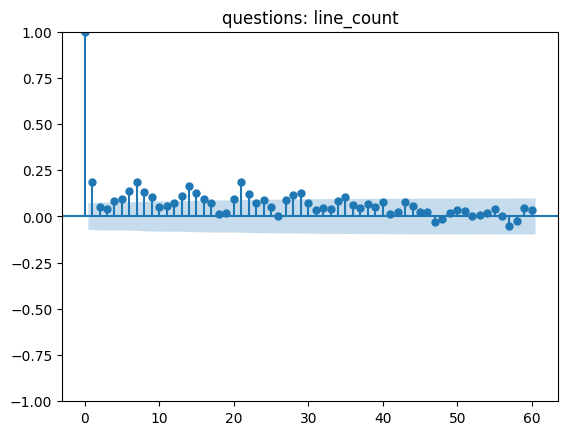

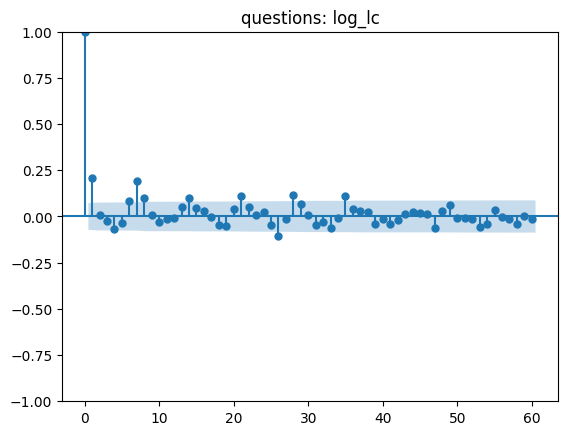

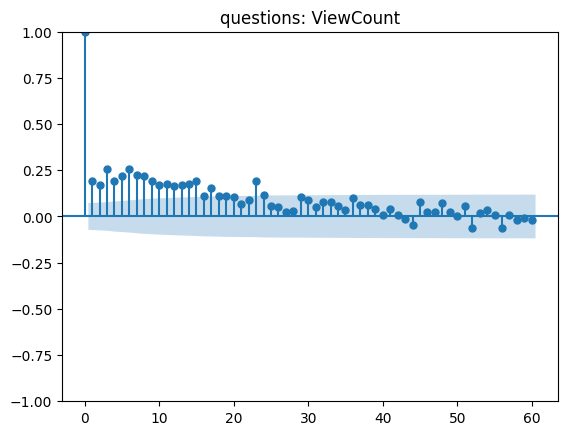

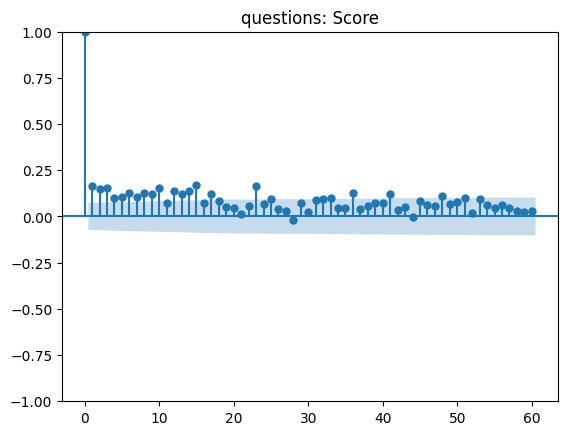

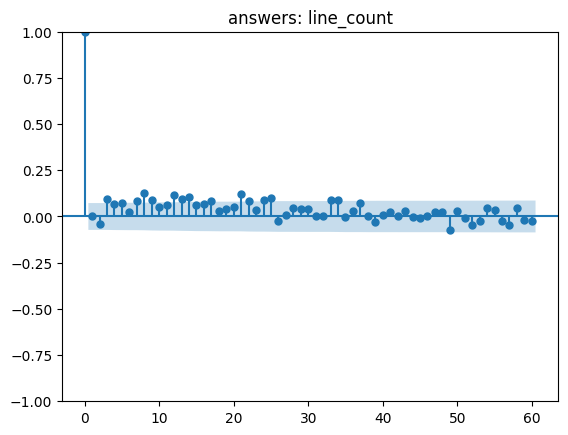

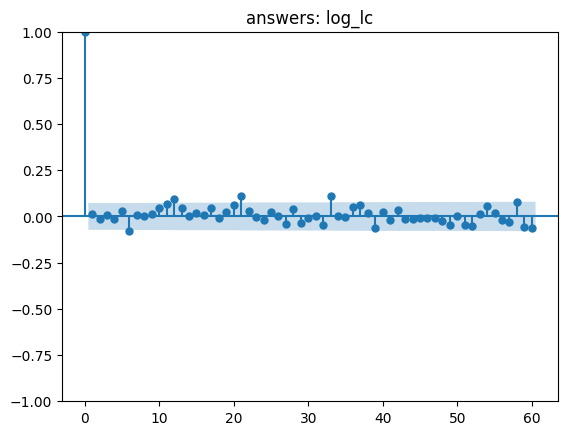

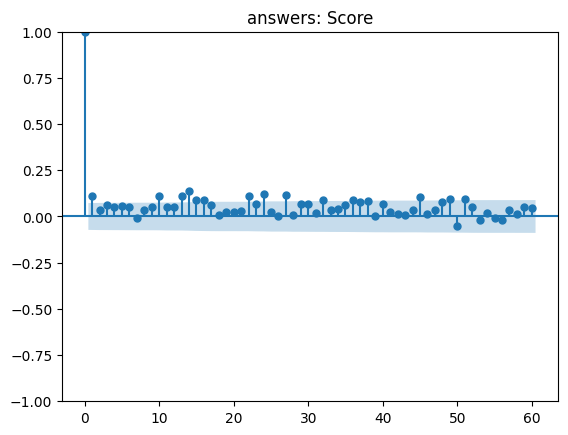

In [7]:
for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            acf(dfs[type], type, outcome) 

### Tag daily time series

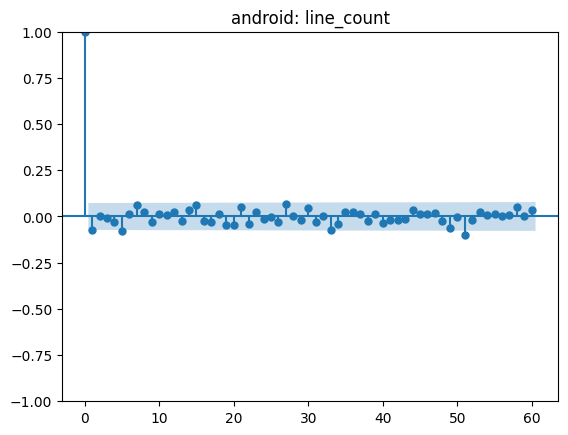

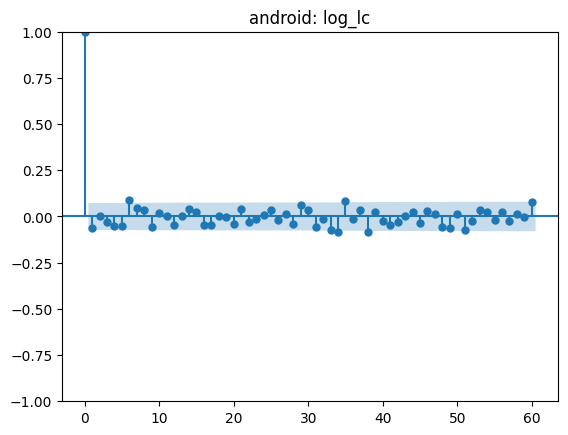

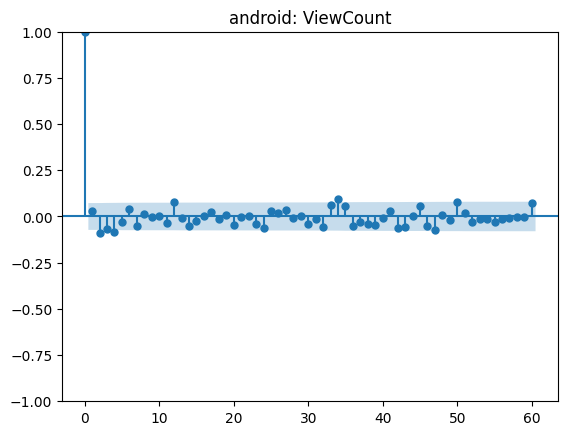

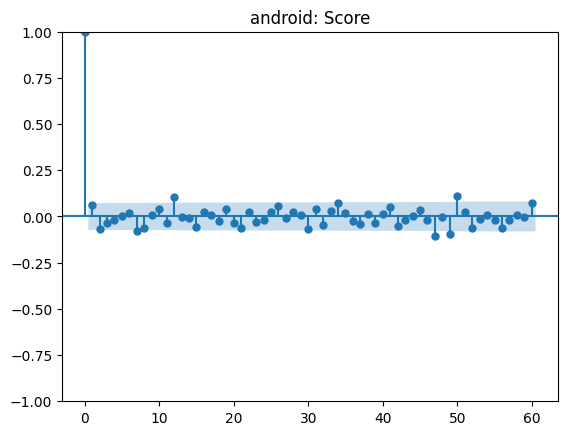

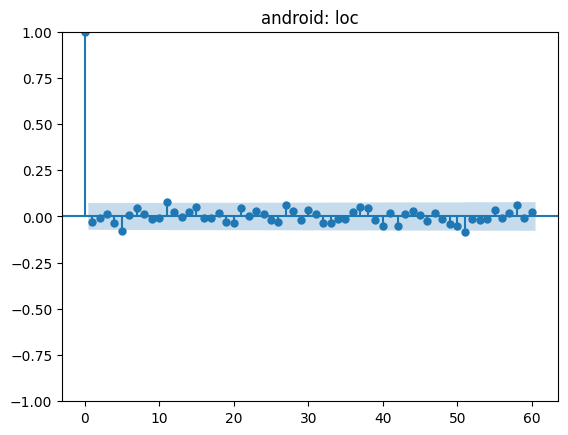

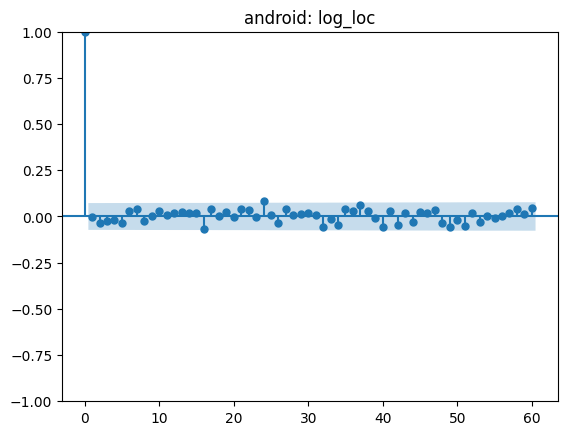

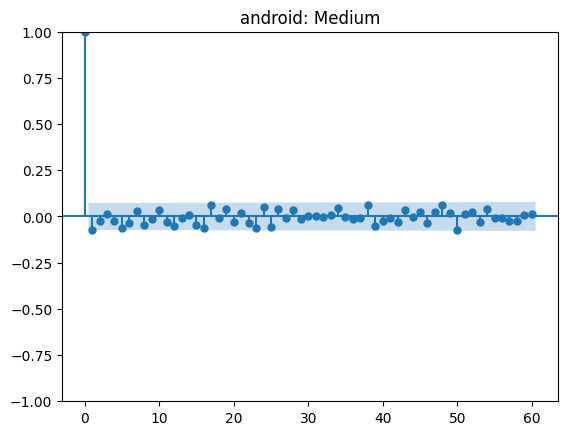

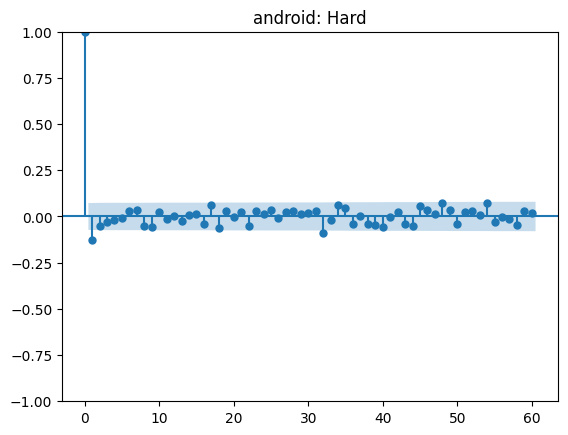

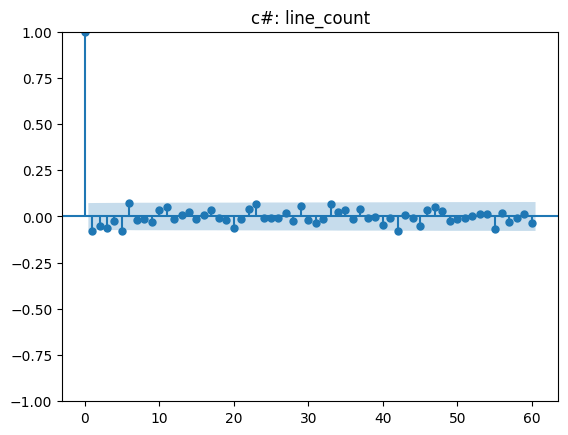

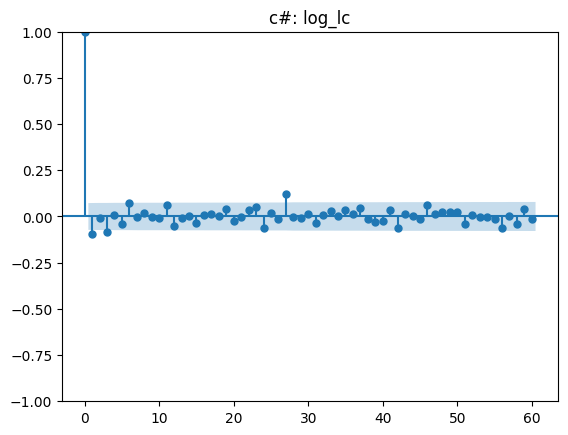

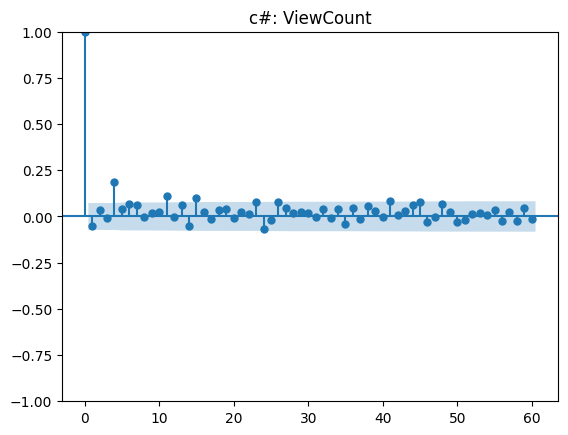

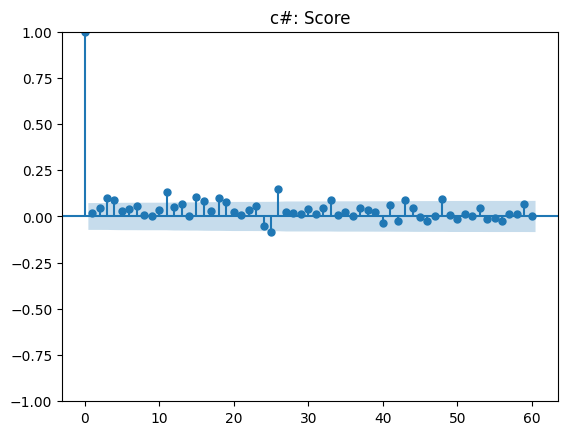

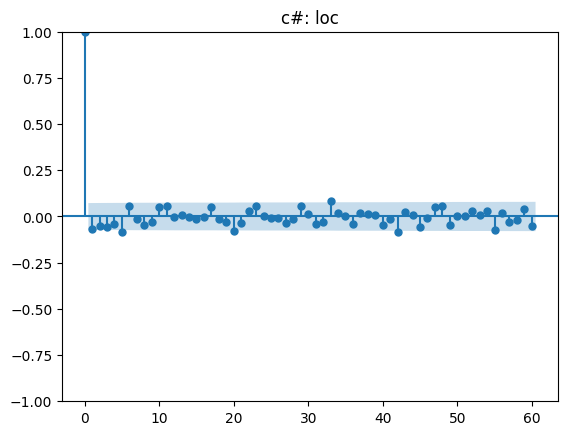

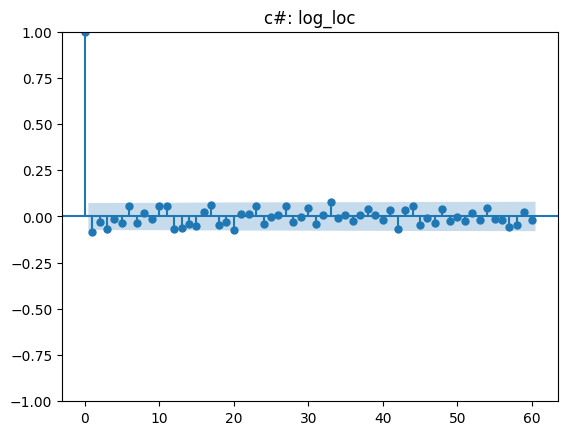

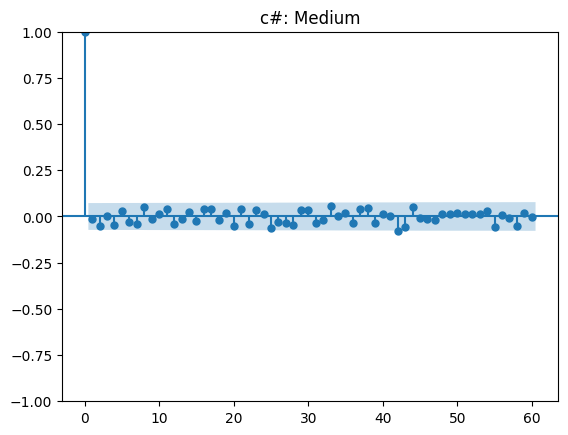

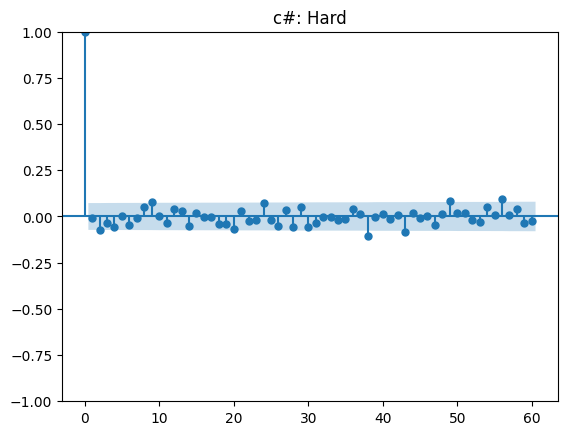

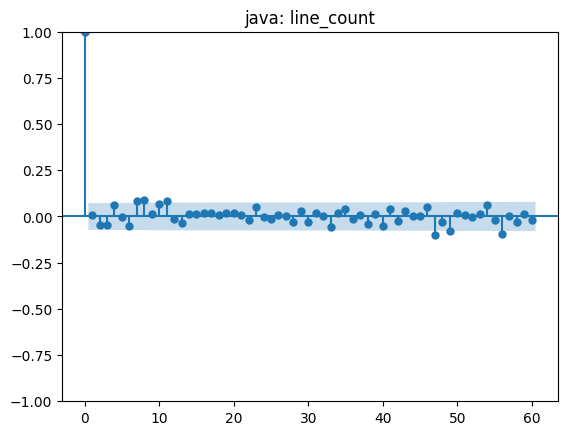

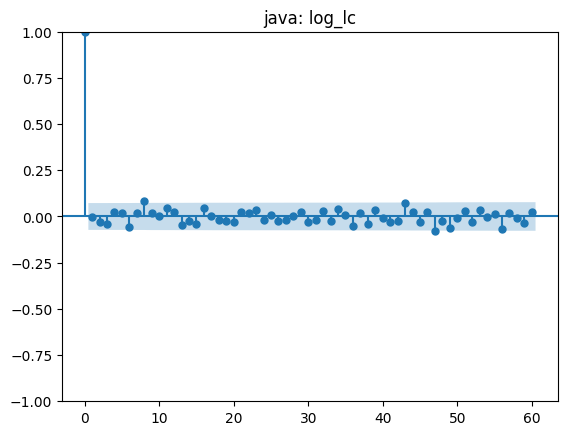

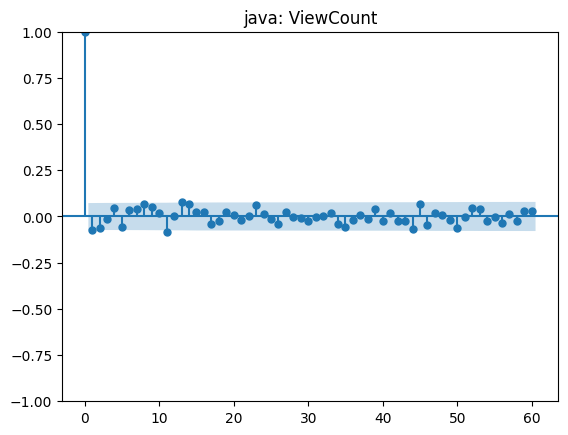

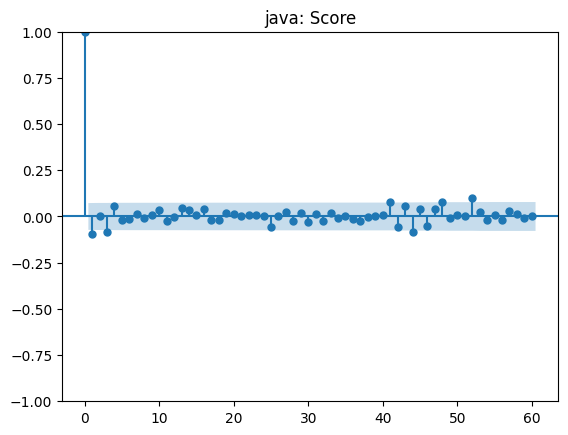

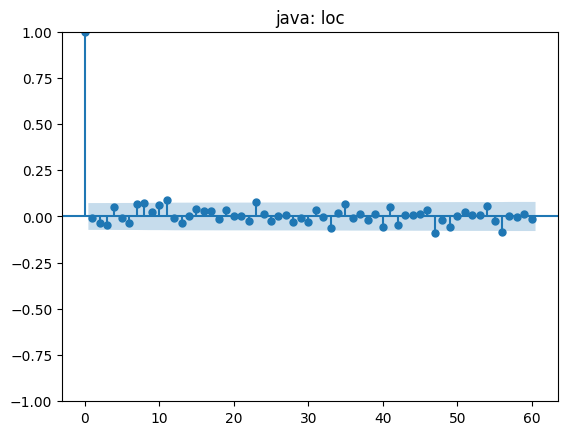

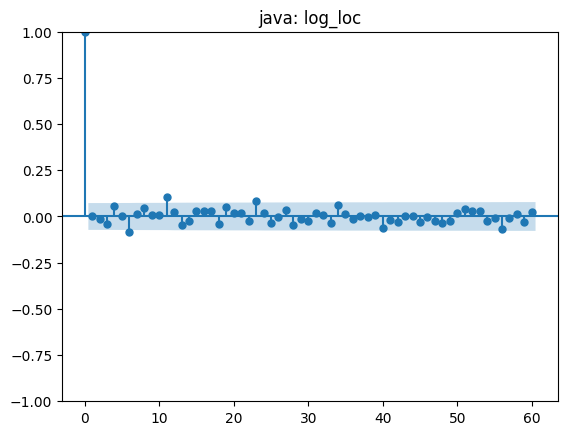

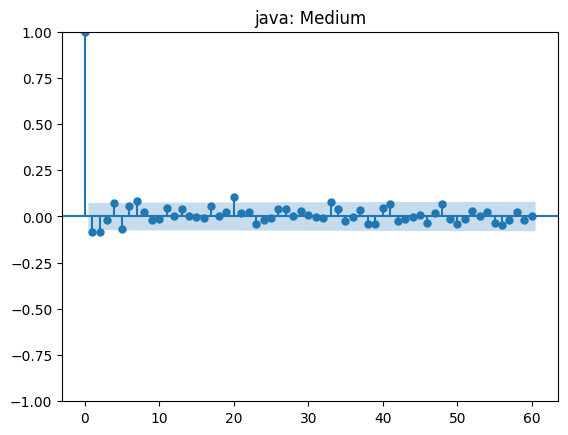

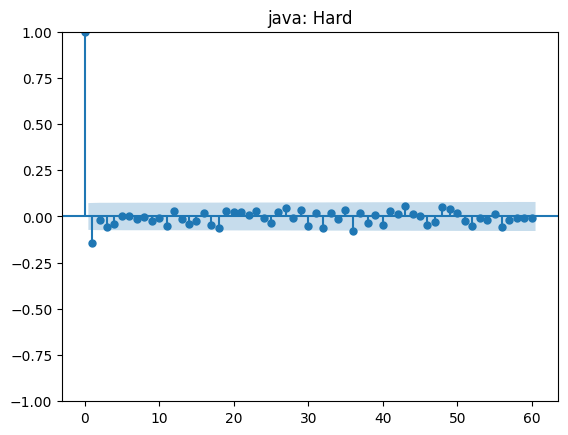

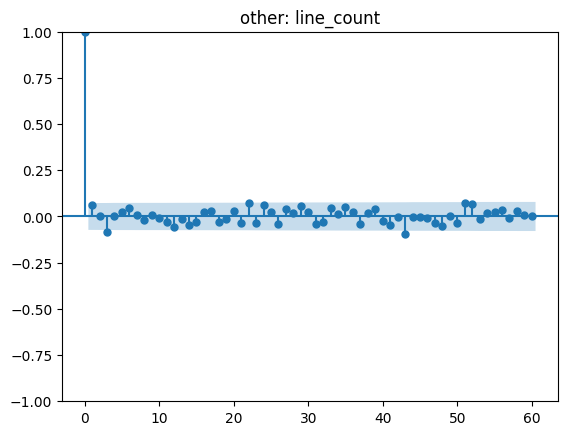

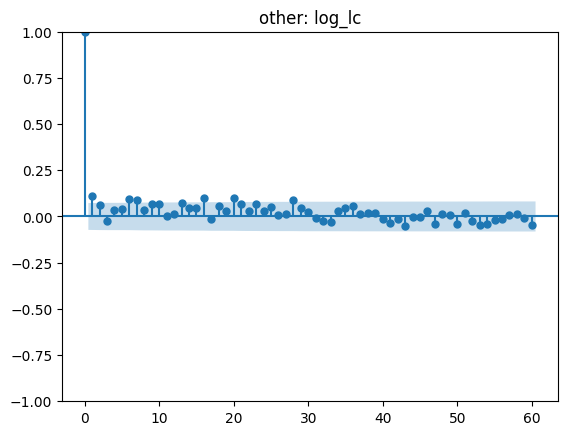

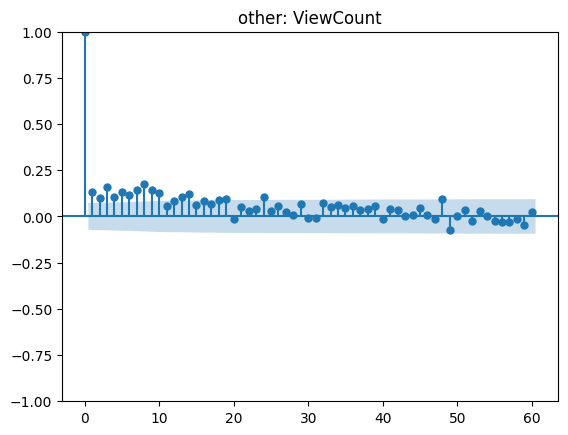

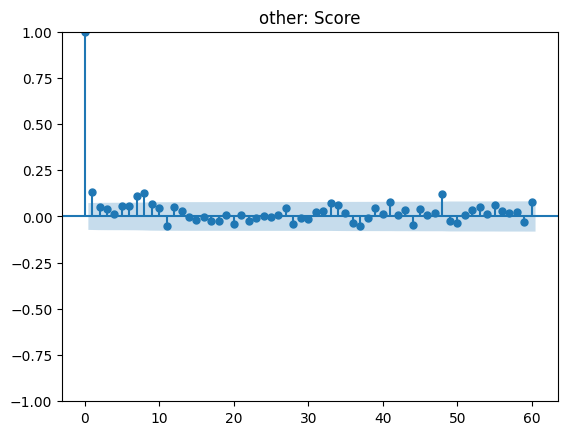

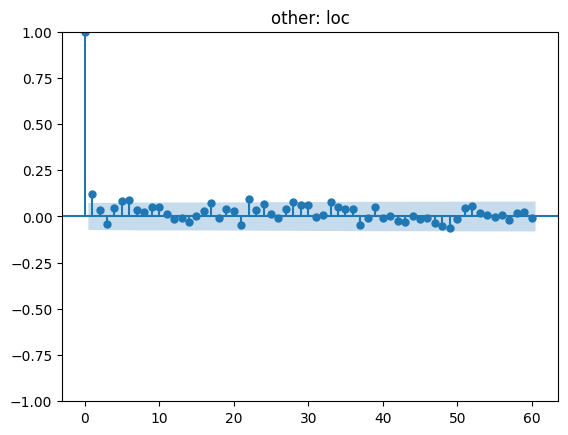

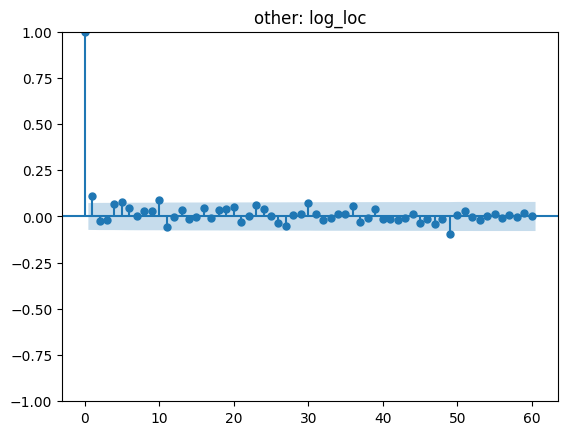

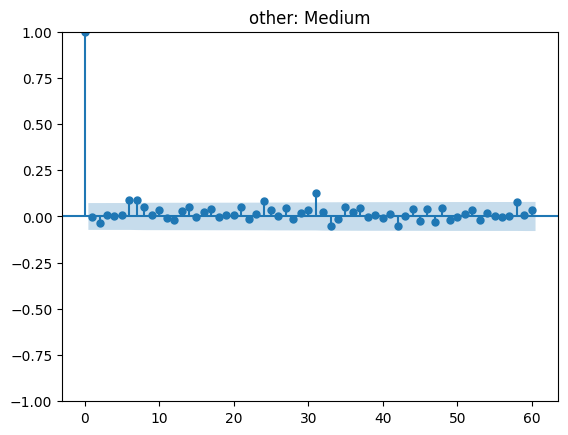

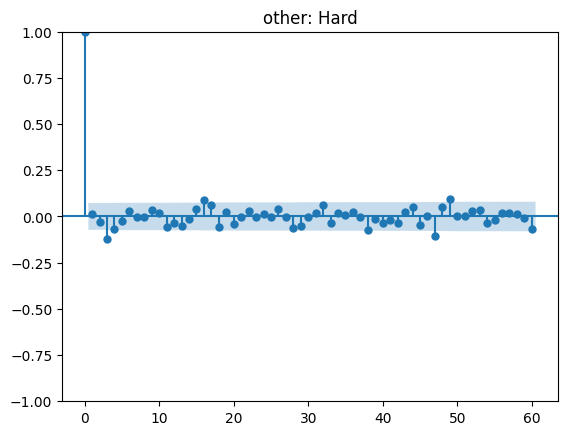

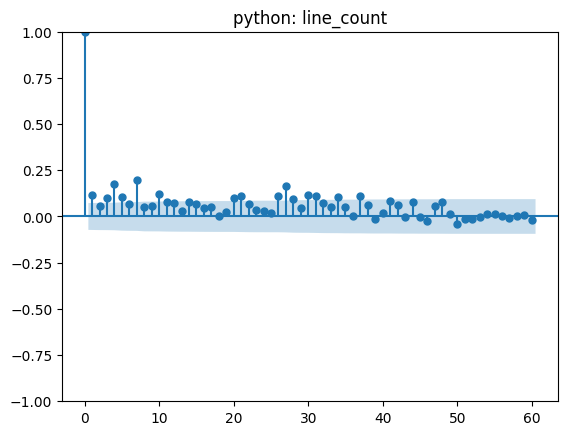

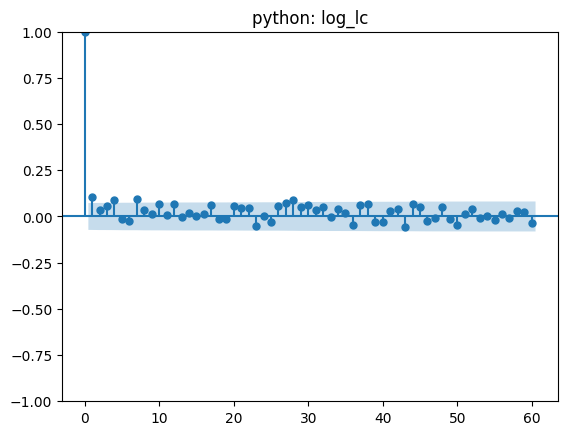

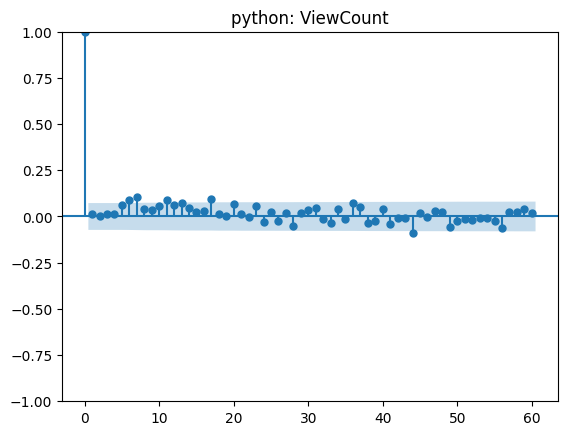

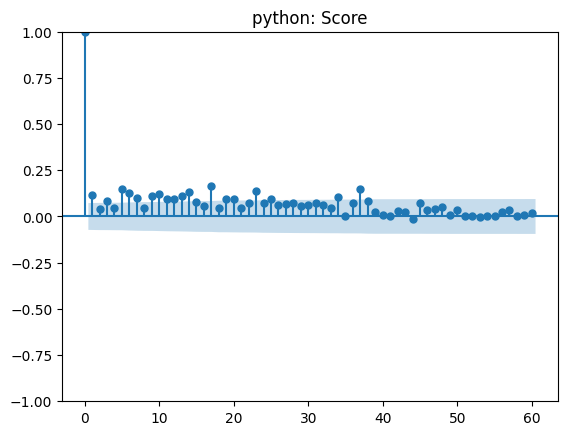

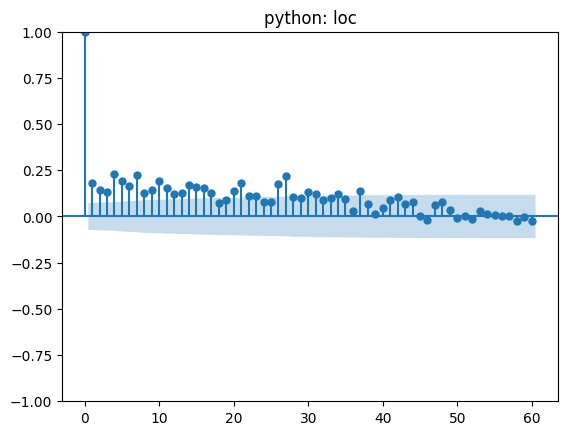

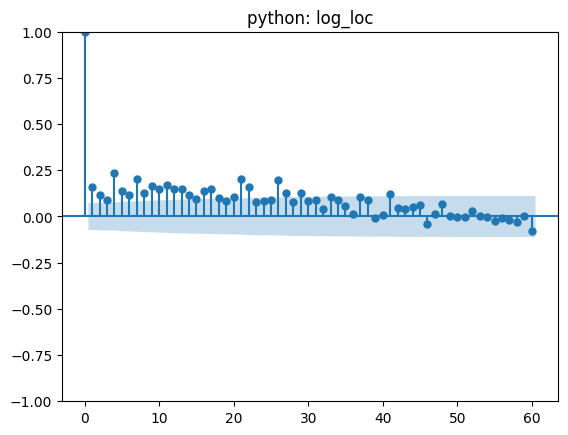

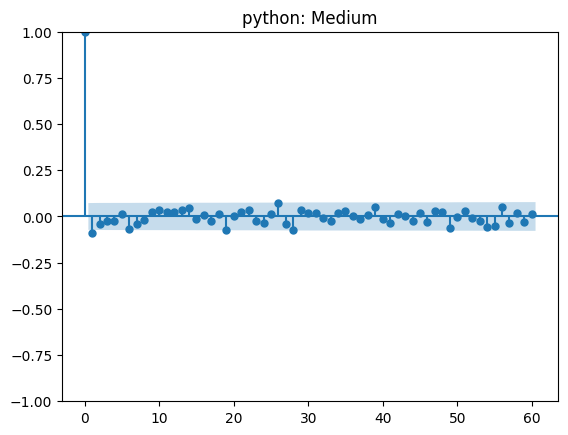

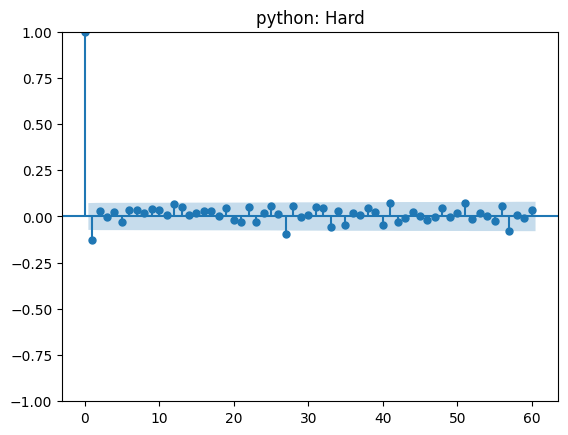

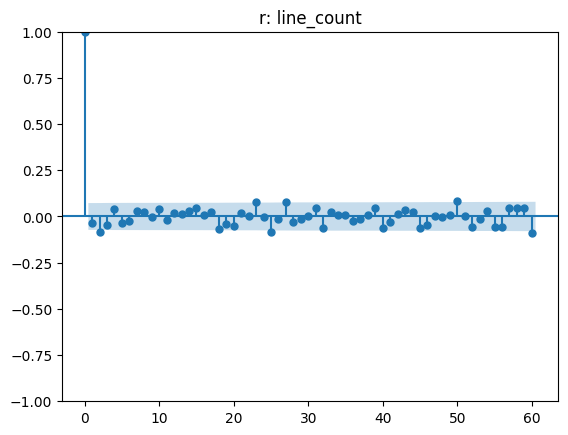

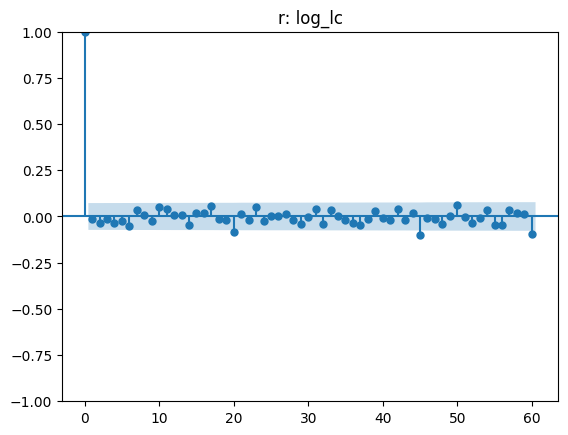

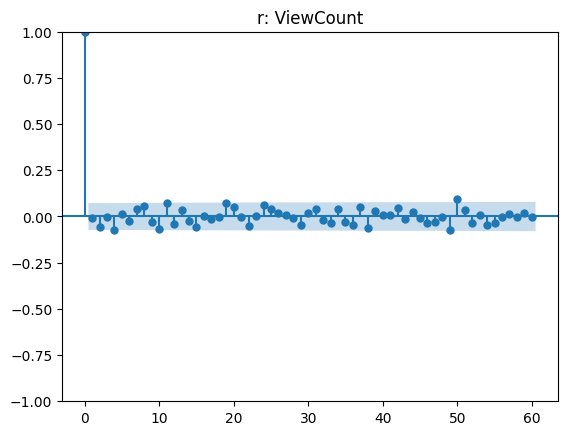

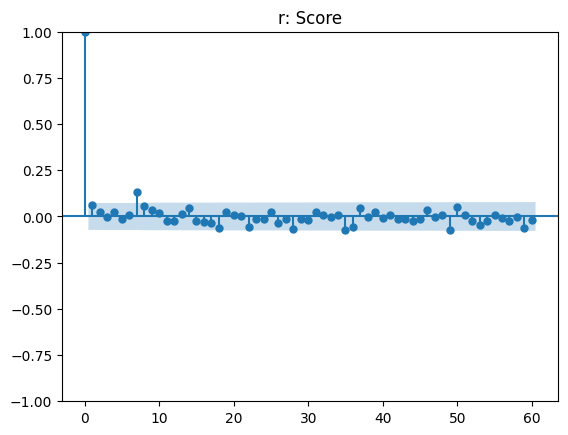

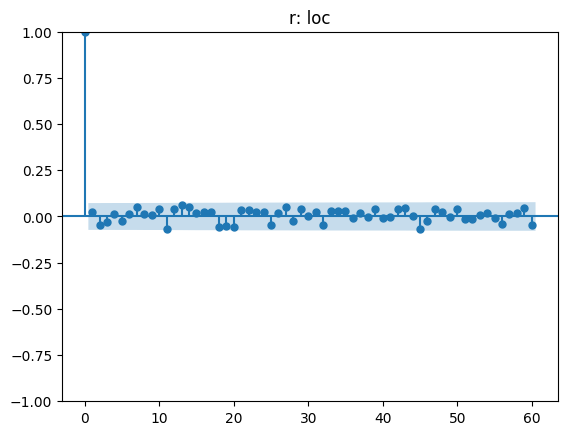

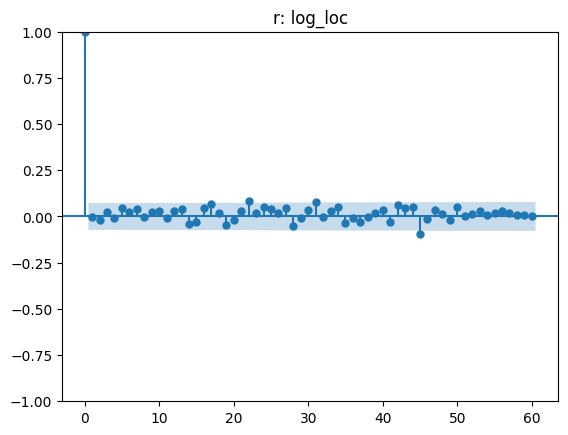

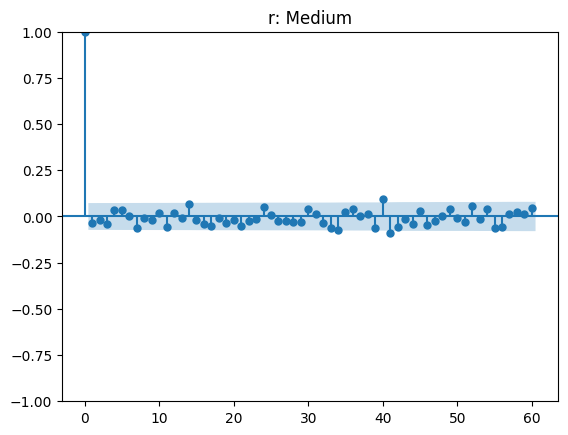

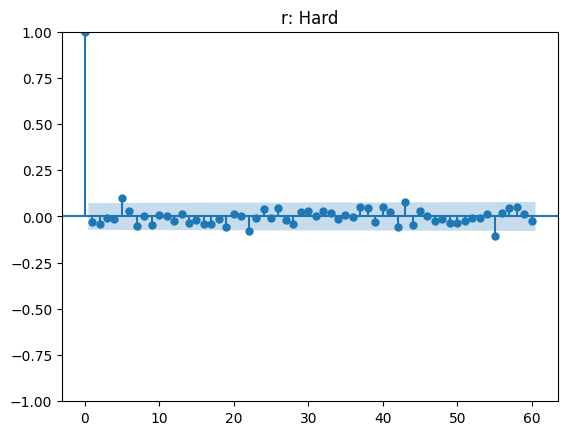

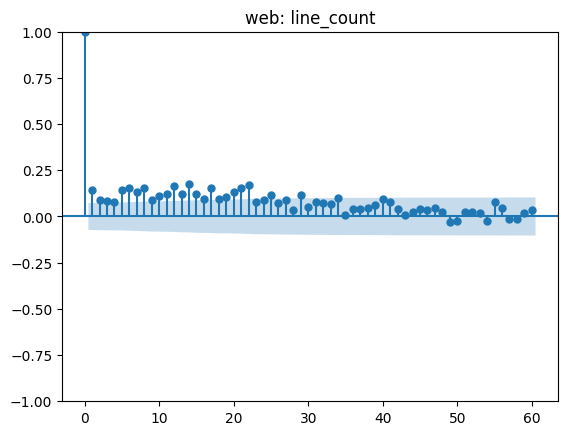

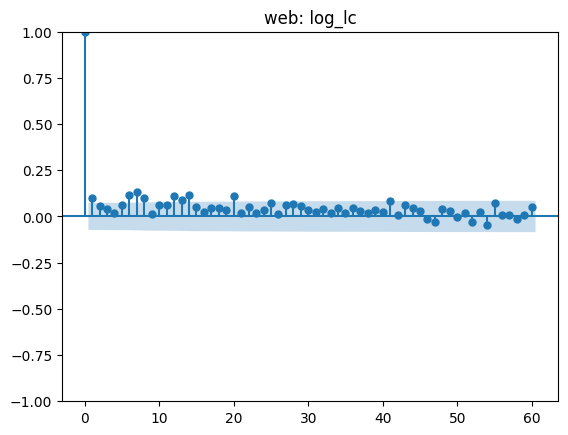

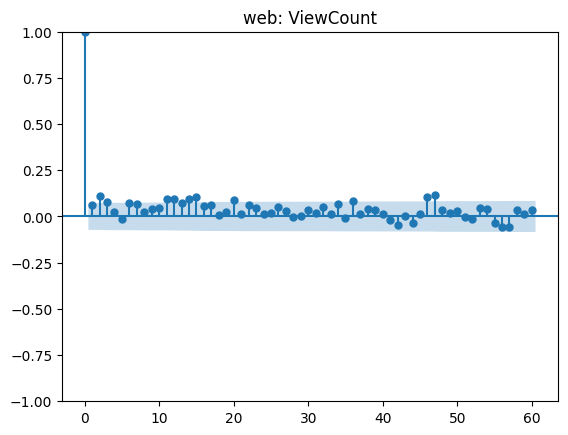

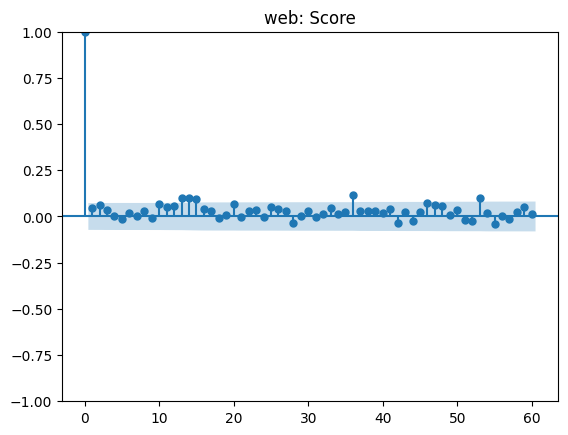

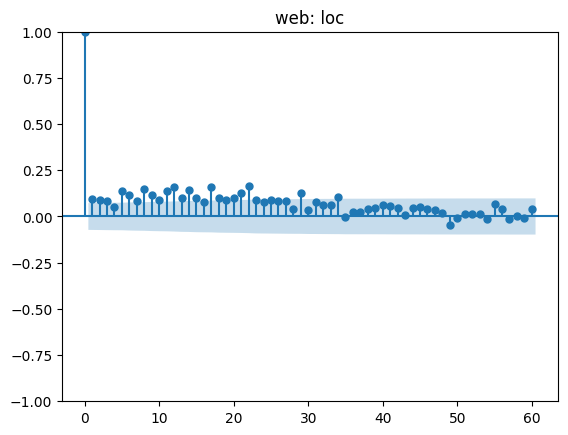

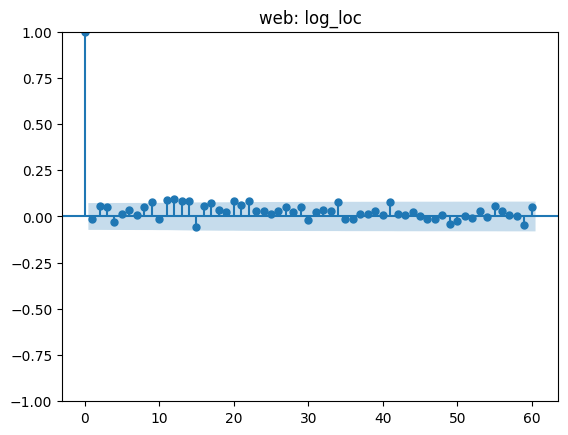

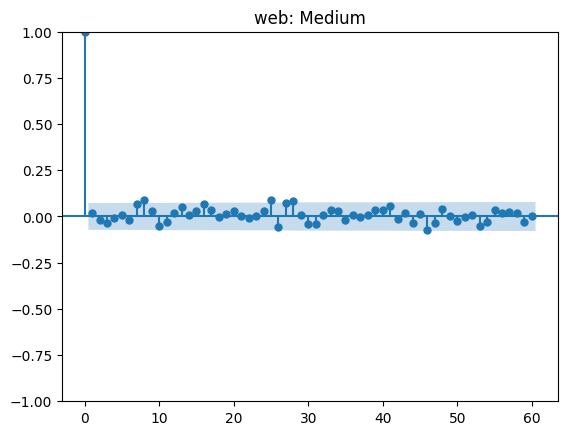

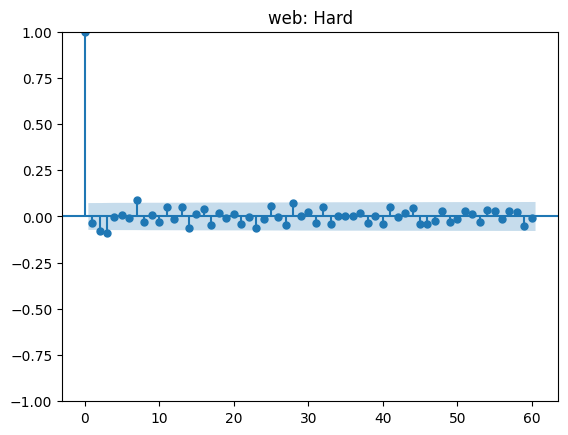

In [8]:
outcomes = ['line_count', 'log_lc', 'ViewCount', 'Score', 'loc', 'log_loc', 'Medium', 'Hard']
for tag in tags:
    for outcome in outcomes:
        acf(tag_dfs[tag], tag, outcome)

# Longest positive effect streak

In [9]:
def resample(dfs, results, outcomes, sample_function=so.block_bootstrap):
    l_hats = {}
    m_hats = {}
    a_hats = {}
    boots = {}
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            print(f'Processing: {type} - {outcome}')
        
            l_hats[(type, outcome)] = so.effect_streak(results[(type, outcome)])
            m_hats[(type, outcome)] = so.max_rolling_mean(results[(type, outcome)])
            a_hats[(type, outcome)] = so.auc(results[(type, outcome)])

            res = so.resample_statistic(dfs[type], outcome, sample_function=sample_function, n_resamples=1000)
            l_boot = [so.effect_streak(b) for b in res]
            m_boot = [so.max_rolling_mean(b) for b in res]
            a_boot = [so.auc(b) for b in res]

            boots[(type, outcome)] = pd.DataFrame({'streak': l_boot, 'max': m_boot, 'auc': a_boot})

    
    return l_hats, m_hats, a_hats, boots

In [10]:
def resample_results(outcomes, hats, boots, statistics='streak'):
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            print('-------------------------------------------')
            print(f'{type}: {outcome}')

            hat = hats[(type, outcome)]
            boot = boots[(type, outcome)][statistics]
            
            print(f'Observed {statistics}:', hat)
            print('Resampled median:', np.median(boot))
            print('Resampled 5% quantile:', np.quantile(boot, 0.05))

            b_95 = np.quantile(boot, 0.05)
            b_90 = np.quantile(boot, 0.10)
            print(f'95% lower bound on {statistics}:', int(b_95))
            print(f'90% lower bound on {statistics}:', int(b_90))

            p = (boot >= hat).mean()
            print('p-value:', p)

            print('95% interval:', np.quantile(boot, [0.025, 0.975]))

            plt.figure()
            sns.histplot(boot)
            plt.title(f'{type}: {outcome} - {statistics}')

## Question/answers

In [11]:
results = so.read_results('qa.csv')

In [12]:
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc']}

### Bootstrap distribution of the effect streak

Processing: questions - log_lc
Iteration: 0/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Iteration: 50/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Iteration: 100/1000


...

Iteration: 900/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Iteration: 950/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


-------------------------------------------
questions: log_lc
Observed streak: 1.0
Resampled median: 1.0
Resampled 5% quantile: 0.5357615894039736
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.698
95% interval: [0.44354305 1.        ]
-------------------------------------------
answers: log_lc
Observed streak: 1.0
Resampled median: 0.5894039735099338
Resampled 5% quantile: 0.2380794701986755
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.151
95% interval: [0.1986755 1.       ]
-------------------------------------------
questions: log_lc
Observed max: 0.07508304697799573
Resampled median: 0.07574642971222709
Resampled 5% quantile: 0.05775478436724954
95% lower bound on max: 0
90% lower bound on max: 0
p-value: 0.531
95% interval: [0.05471832 0.09450474]
-------------------------------------------
answers: log_lc
Observed max: 0.04052282424492403
Resampled median: 0.03652224472954091
Resampled 5% quantile: 0.02199226685481768
95% lower bound 

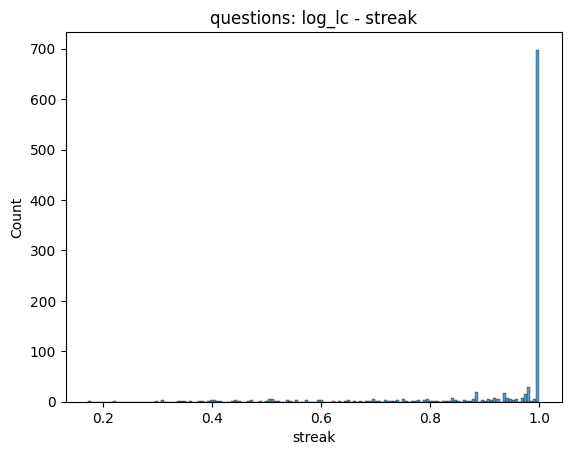

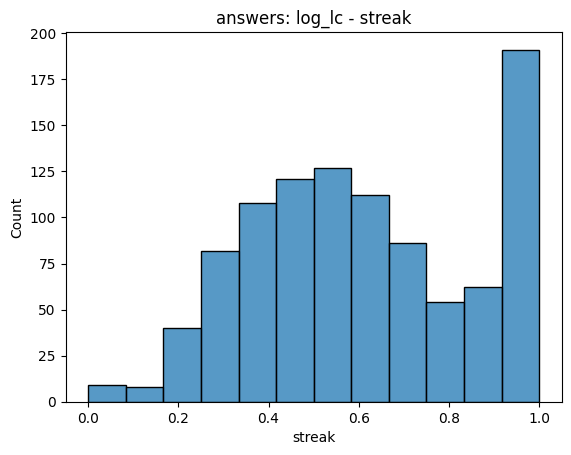

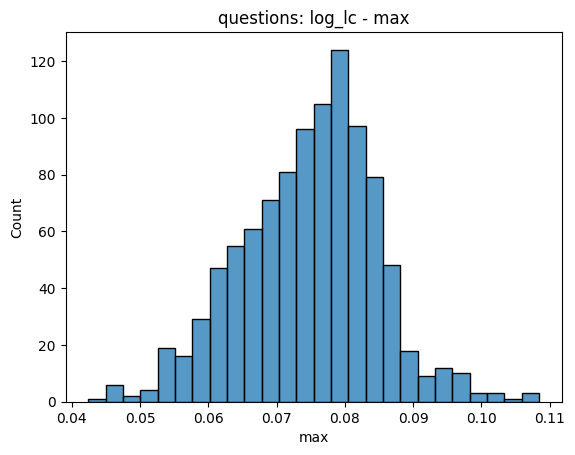

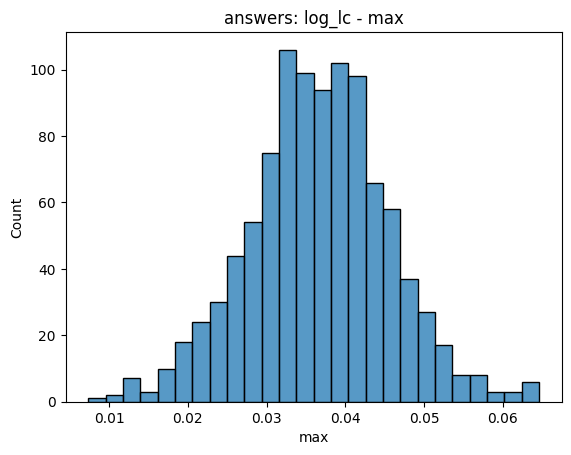

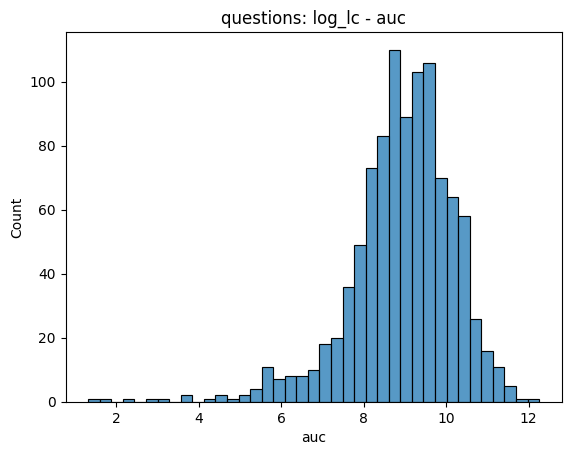

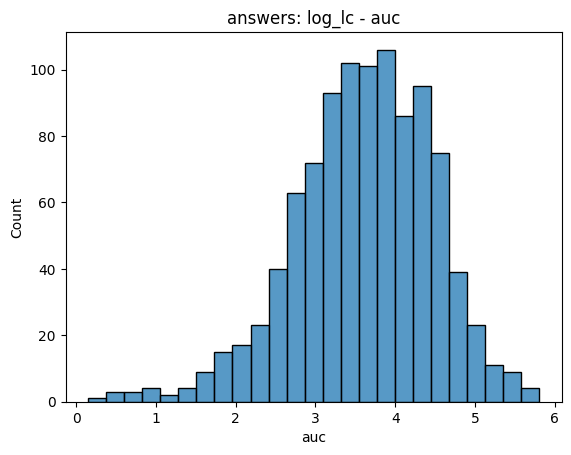

In [13]:
l_hats, m_hats, a_hats, boots = resample(dfs, results, outcomes)
so.store_results(boots, 'qa_boot.csv')
resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

### Permutation distribution of the effect streak

Processing: questions - log_lc
Iteration: 0/1000
Iteration: 50/1000
Iteration: 100/1000
Iteration: 150/1000
Iteration: 200/1000
Iteration: 250/1000
Iteration: 300/1000
Iteration: 350/1000
Iteration: 400/1000
Iteration: 450/1000
Iteration: 500/1000
Iteration: 550/1000
Iteration: 600/1000
Iteration: 650/1000
Iteration: 700/1000
Iteration: 750/1000
Iteration: 800/1000
Iteration: 850/1000
Iteration: 900/1000
Iteration: 950/1000
Processing: answers - log_lc
Iteration: 0/1000
Iteration: 50/1000
Iteration: 100/1000
Iteration: 150/1000
Iteration: 200/1000
Iteration: 250/1000
Iteration: 300/1000
Iteration: 350/1000
Iteration: 400/1000
Iteration: 450/1000
Iteration: 500/1000
Iteration: 550/1000
Iteration: 600/1000
Iteration: 650/1000
Iteration: 700/1000
Iteration: 750/1000
Iteration: 800/1000
Iteration: 850/1000
Iteration: 900/1000
Iteration: 950/1000
-------------------------------------------
questions: log_lc
Observed streak: 1.0
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower boun

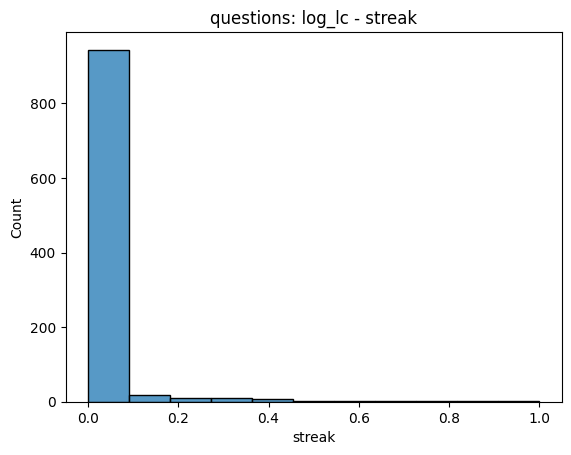

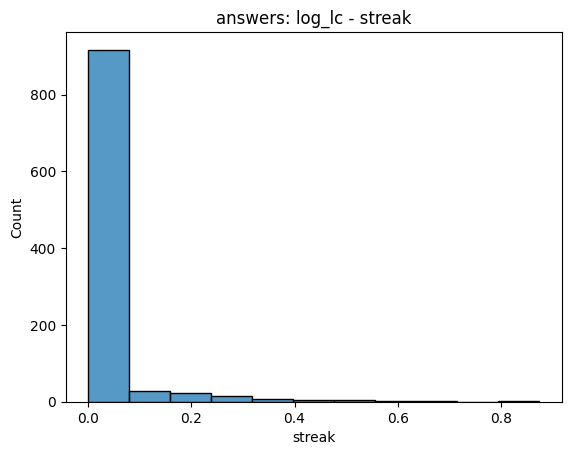

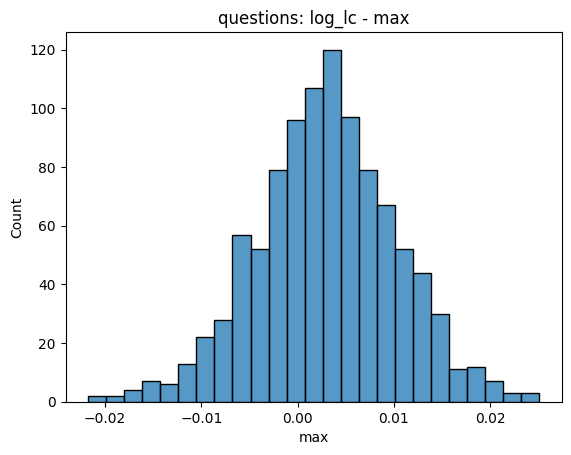

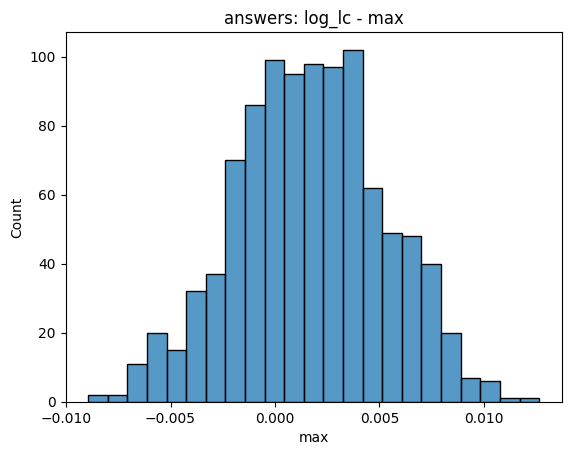

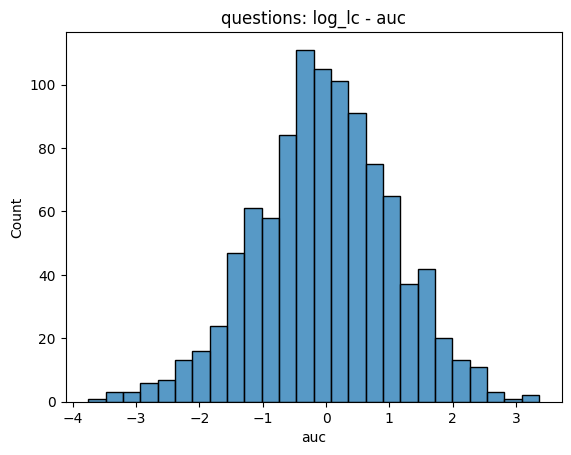

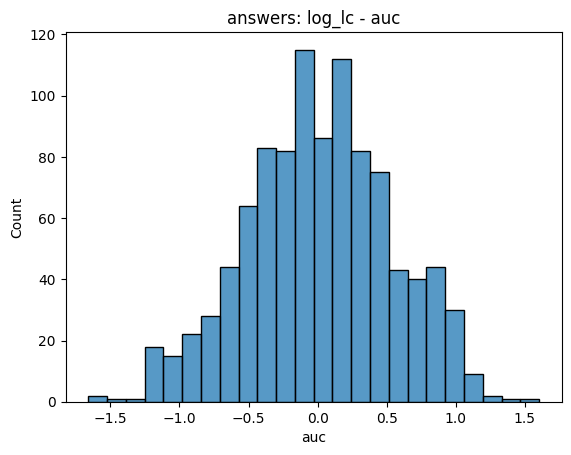

In [14]:
l_hats, m_hats, a_hats, boots = resample(dfs, results, outcomes, sample_function=so.permute_treatment)
so.store_results(boots, 'qa_perm.csv')
resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

## Tags

In [15]:
tag_results = so.read_results('tags.csv')

In [16]:
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'java': targets, 'python': targets, 'web': targets}

Processing: java - log_lc
Iteration: 0/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Iteration: 50/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Iteration: 100/1000


...

/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Iteration: 950/1000


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


-------------------------------------------
java: log_lc
Observed streak: 0.6490066225165563
Resampled median: 0.3576158940397351
Resampled 5% quantile: 0.16523178807947023
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.109
95% interval: [0.13245033 1.        ]
-------------------------------------------
java: log_loc
Observed streak: 0.4105960264900662
Resampled median: 0.1986754966887417
Resampled 5% quantile: 0.0728476821192053
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.094
95% interval: [0.05960265 0.64917219]
-------------------------------------------
java: Medium
Observed streak: 0.4105960264900662
Resampled median: 0.2185430463576159
Resampled 5% quantile: 0.059602649006622516
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.077
95% interval: [0.0397351  0.52980132]
-------------------------------------------
python: log_lc
Observed streak: 1.0
Resampled median: 0.9668874172185431
Resampled 5% quantile: 0.38410

/tmp/ipykernel_876244/2218253018.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


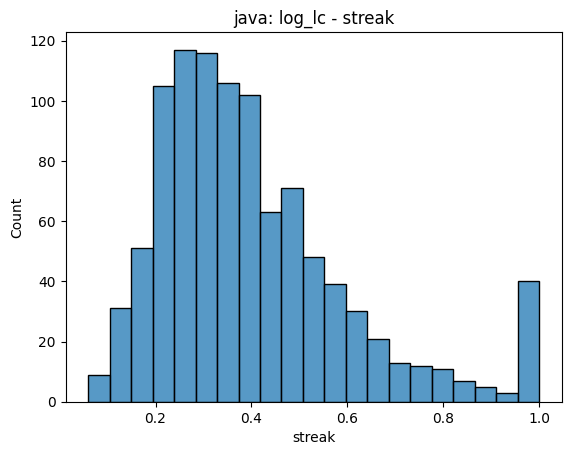

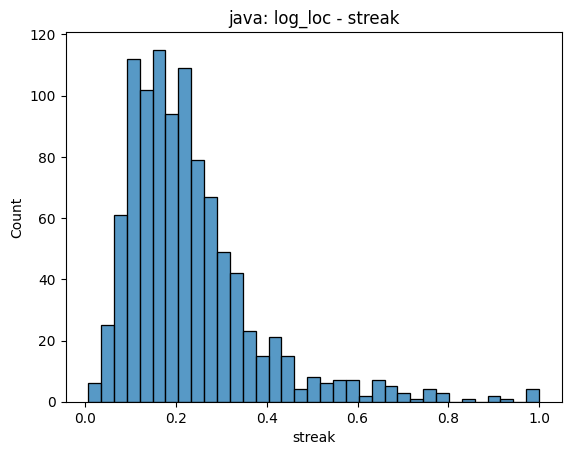

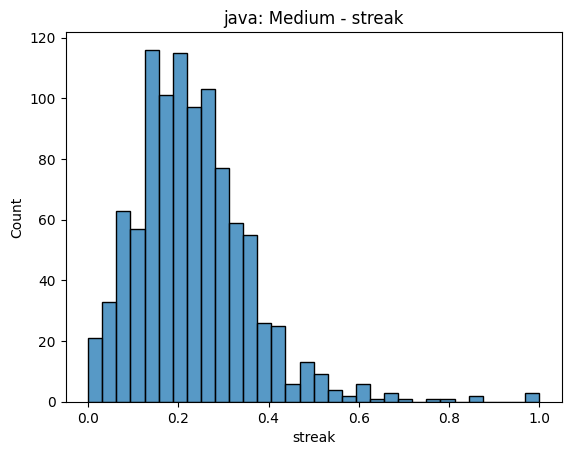

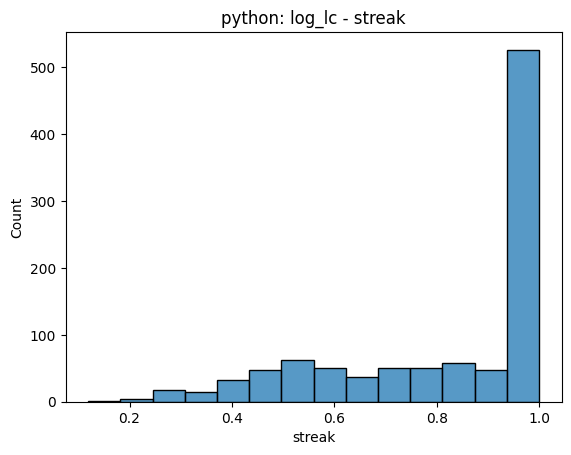

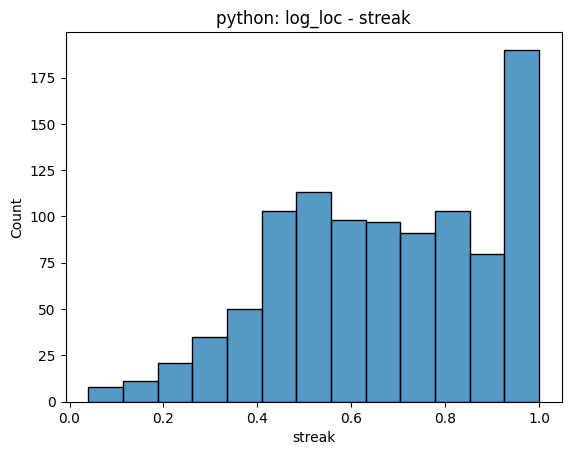

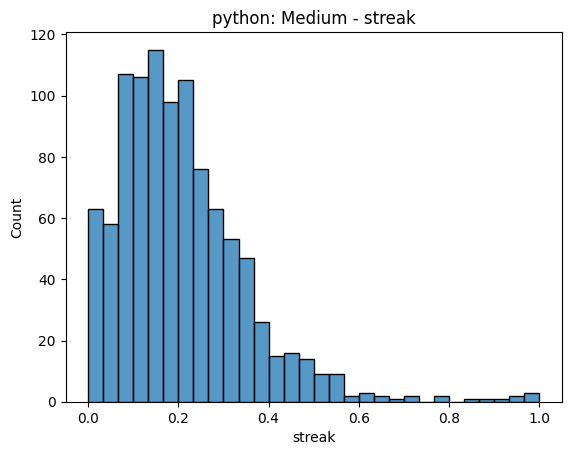

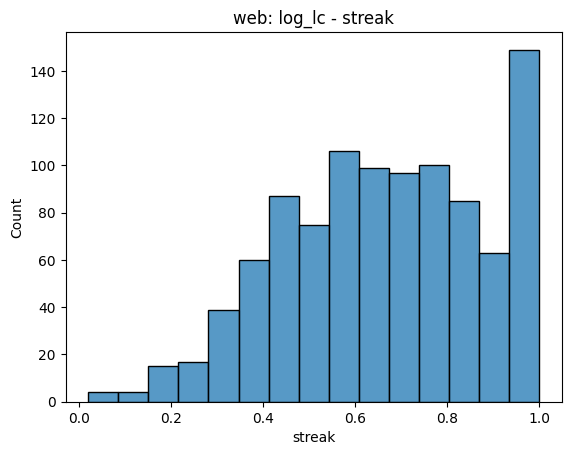

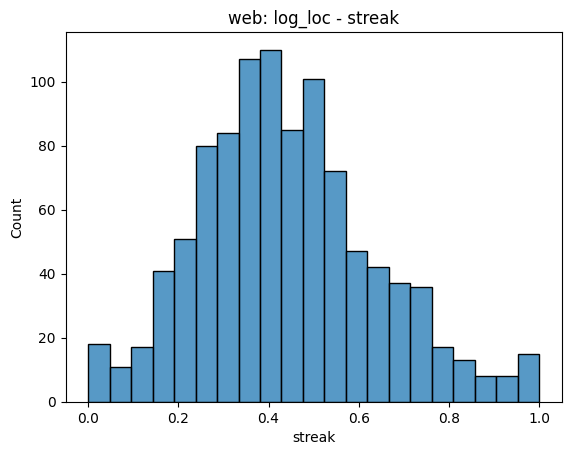

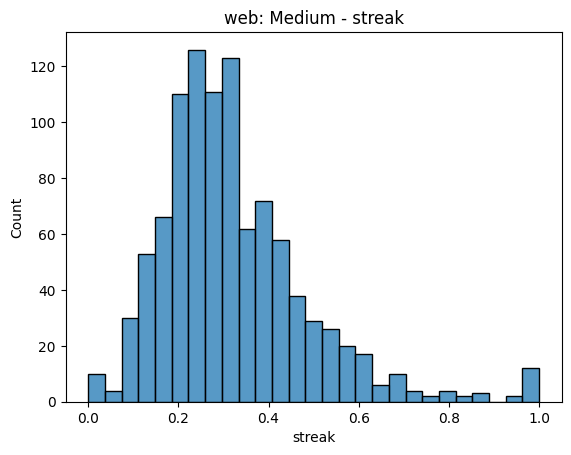

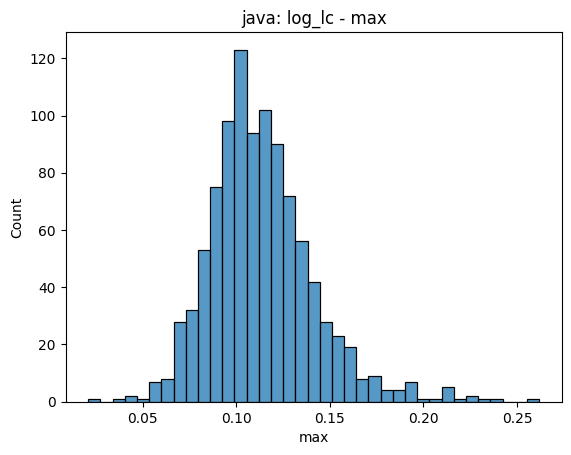

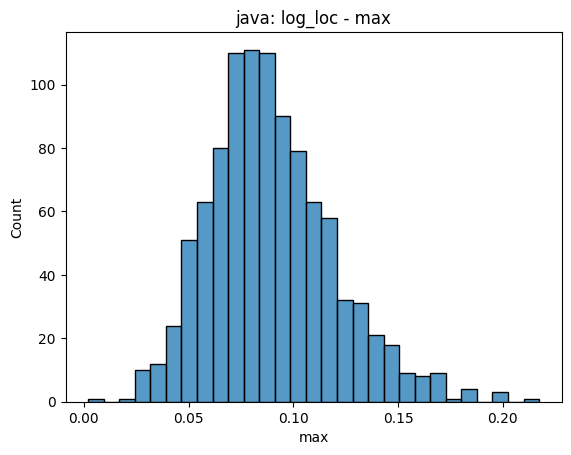

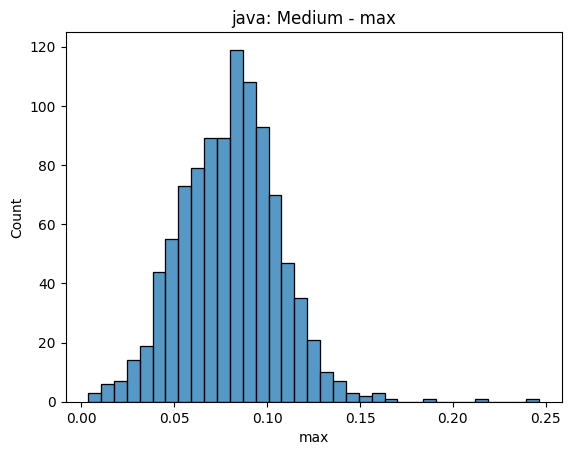

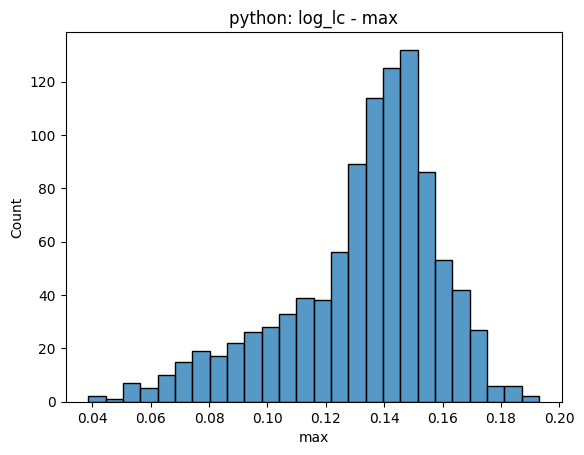

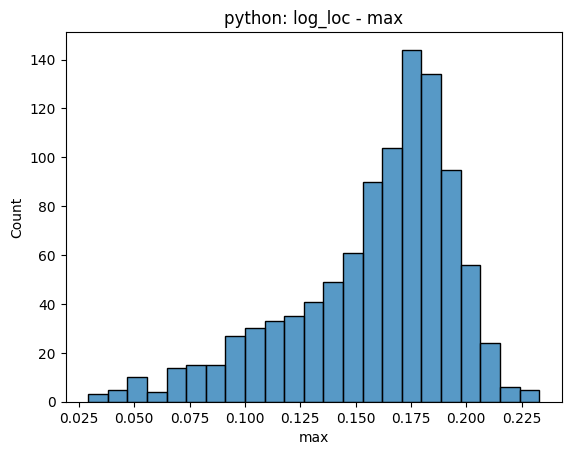

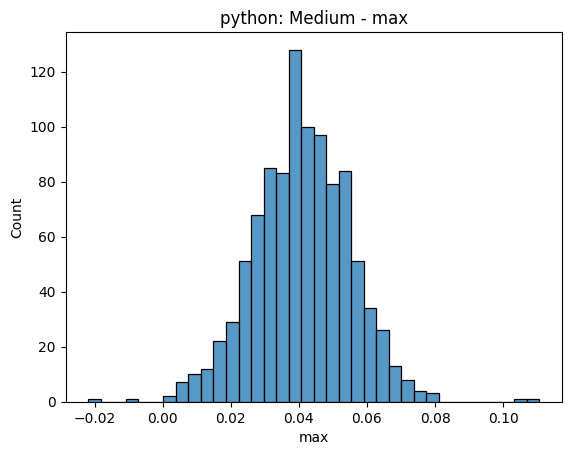

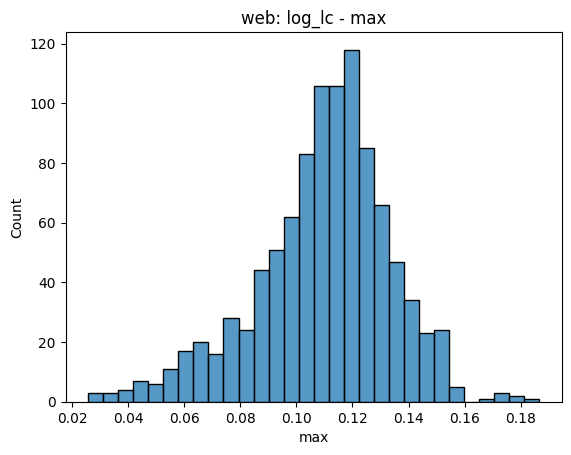

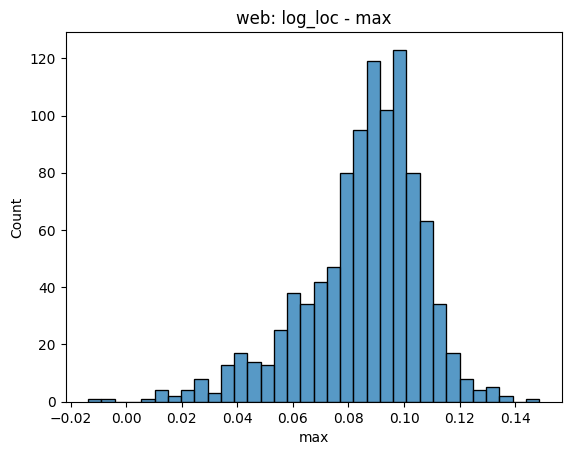

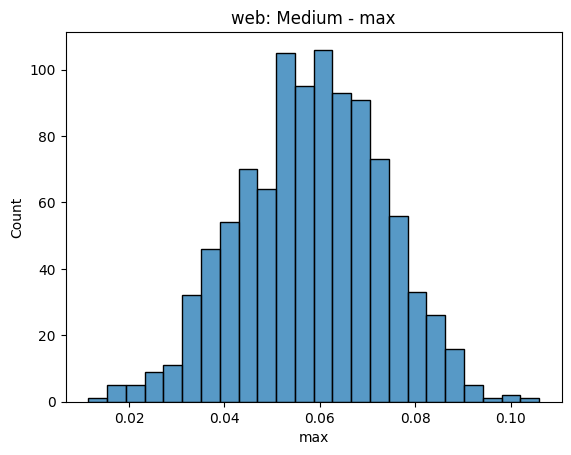

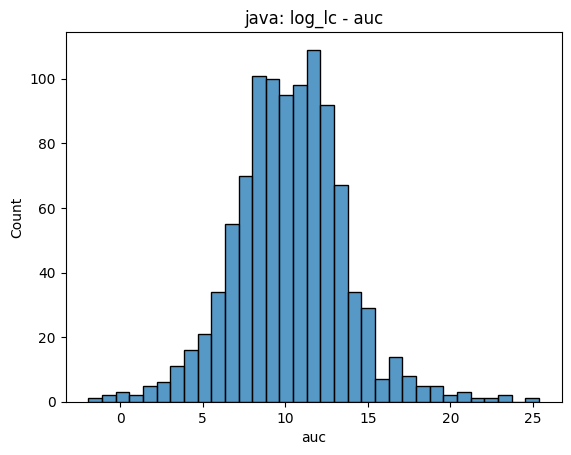

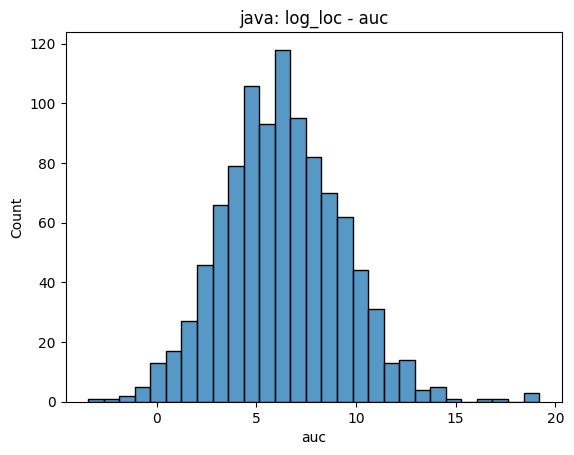

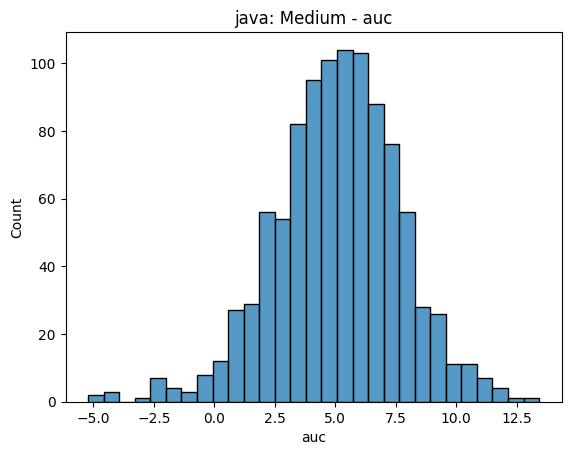

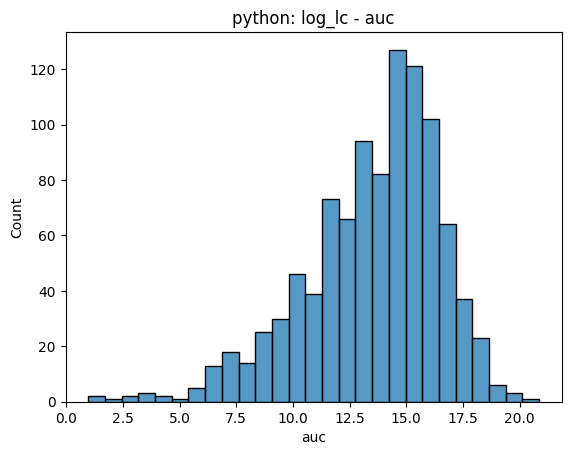

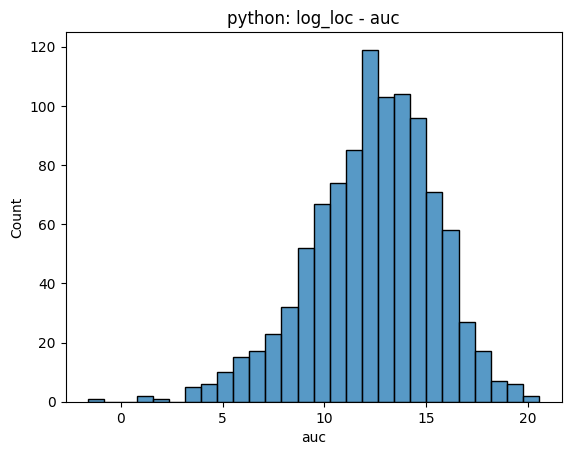

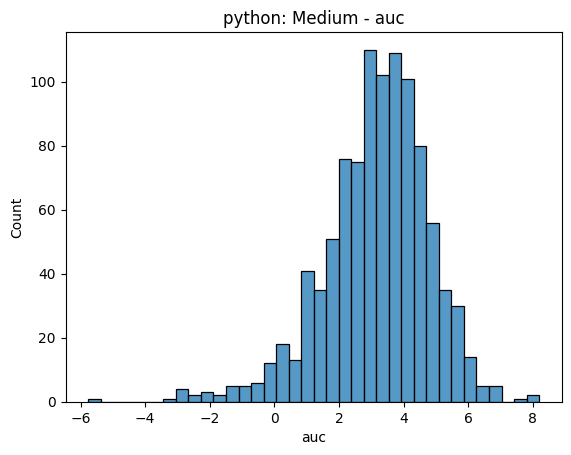

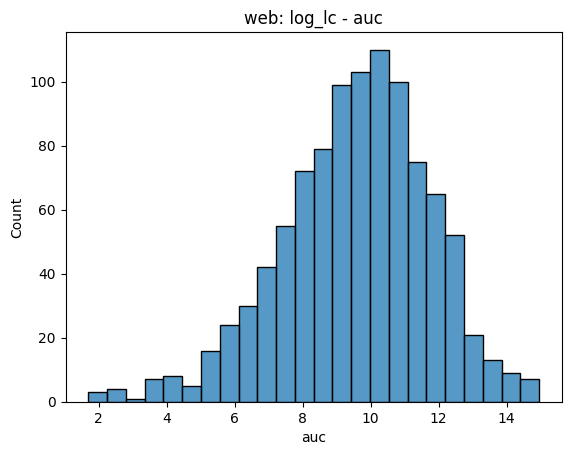

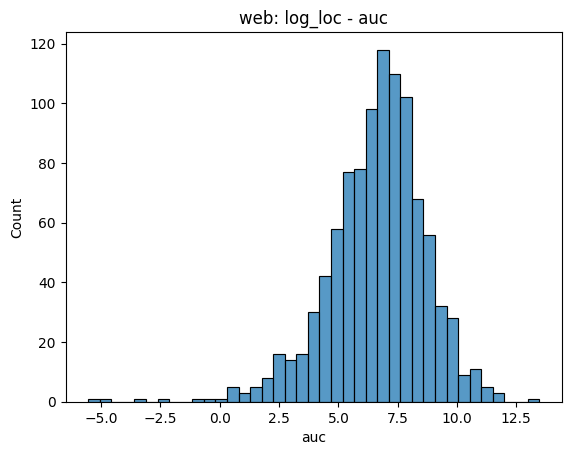

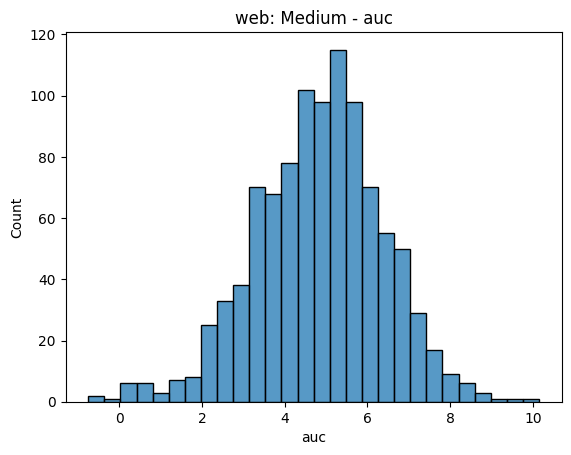

In [17]:
l_hats, m_hats, a_hats, boots = resample(tag_dfs, tag_results, outcomes)
so.store_results(boots, 'tags_boot.csv')
resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

Processing: java - log_lc
Iteration: 0/1000
Iteration: 50/1000
Iteration: 100/1000
Iteration: 150/1000
Iteration: 200/1000
Iteration: 250/1000
Iteration: 300/1000
Iteration: 350/1000
Iteration: 400/1000
Iteration: 450/1000
Iteration: 500/1000
Iteration: 550/1000
Iteration: 600/1000
Iteration: 650/1000
Iteration: 700/1000
Iteration: 750/1000
Iteration: 800/1000
Iteration: 850/1000
Iteration: 900/1000
Iteration: 950/1000
Processing: java - log_loc
Iteration: 0/1000
Iteration: 50/1000
Iteration: 100/1000
Iteration: 150/1000
Iteration: 200/1000
Iteration: 250/1000
Iteration: 300/1000
Iteration: 350/1000
Iteration: 400/1000
Iteration: 450/1000
Iteration: 500/1000
Iteration: 550/1000
Iteration: 600/1000
Iteration: 650/1000
Iteration: 700/1000
Iteration: 750/1000
Iteration: 800/1000
Iteration: 850/1000
Iteration: 900/1000
Iteration: 950/1000
Processing: java - Medium
Iteration: 0/1000
Iteration: 50/1000
Iteration: 100/1000
Iteration: 150/1000
Iteration: 200/1000
Iteration: 250/1000
Iteration:

/tmp/ipykernel_876244/2218253018.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


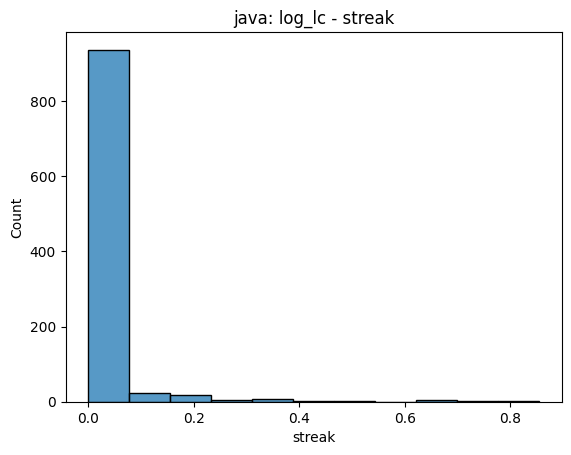

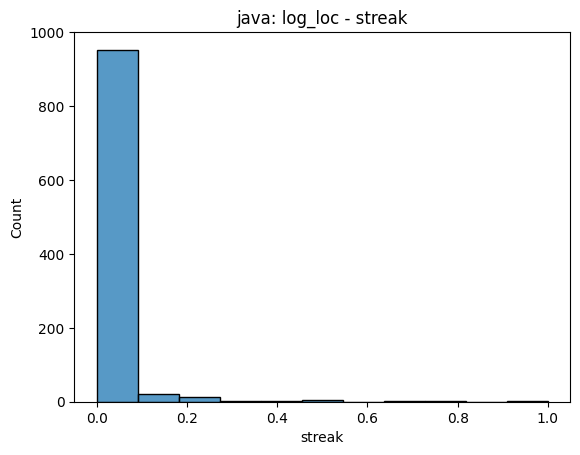

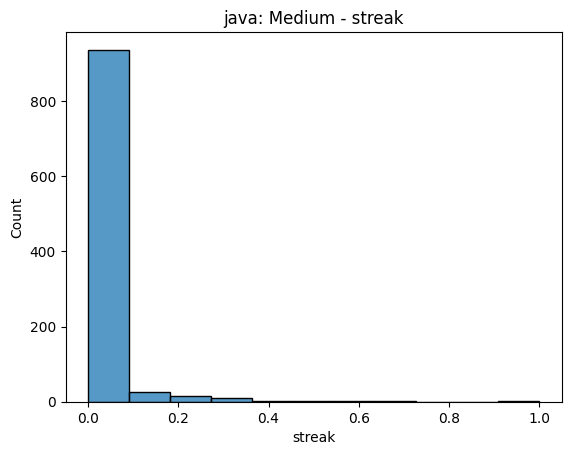

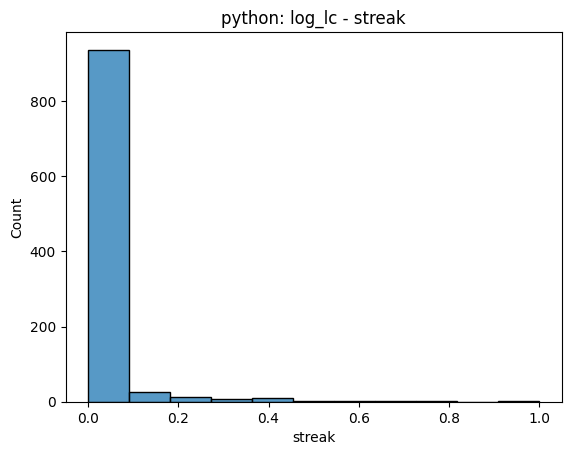

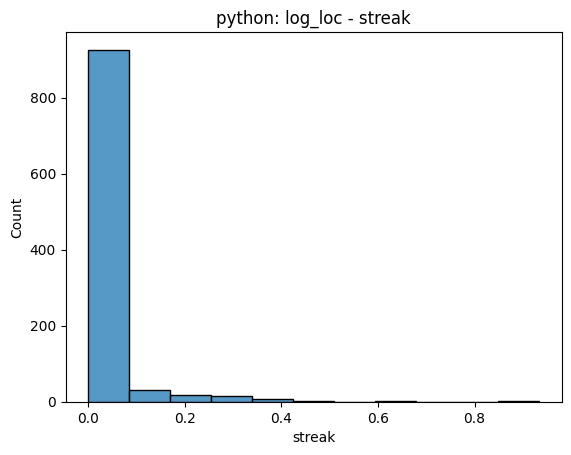

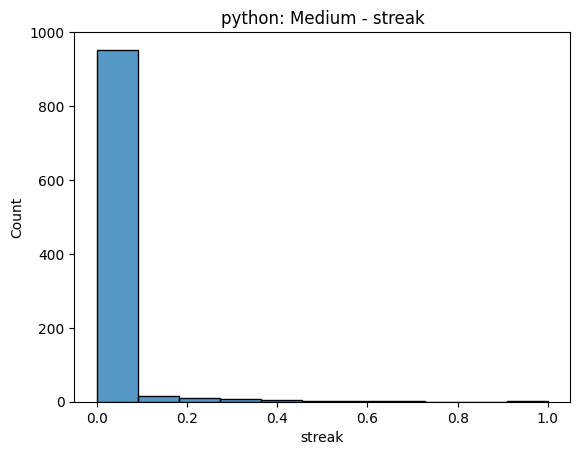

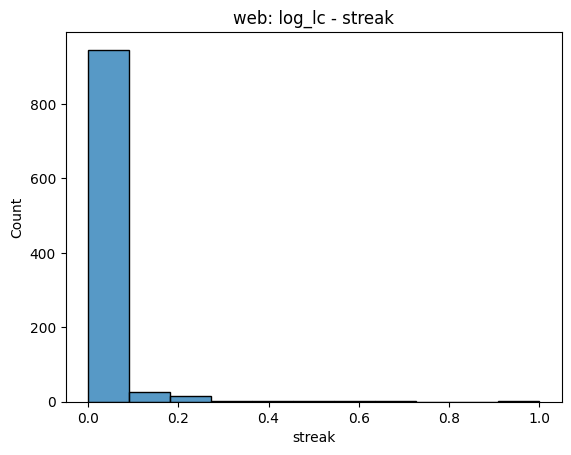

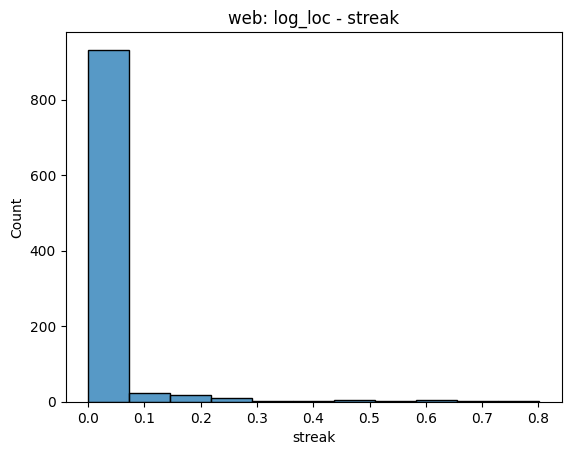

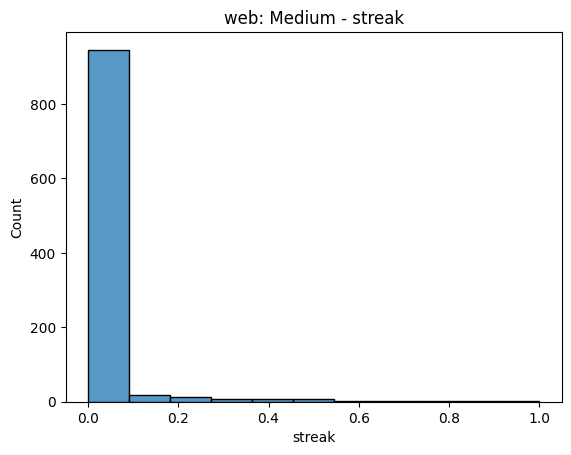

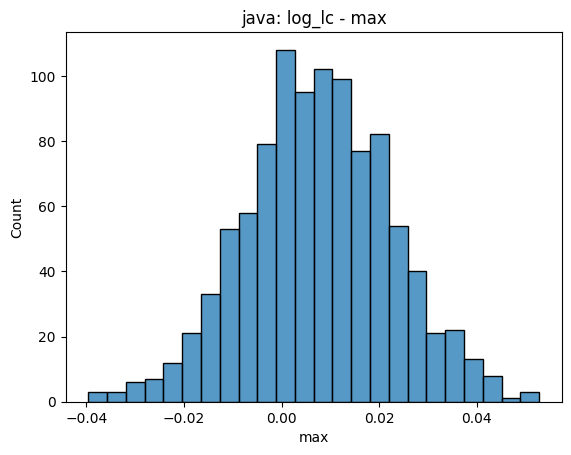

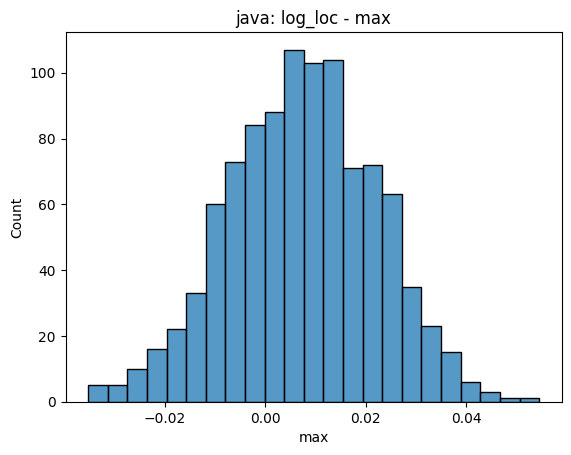

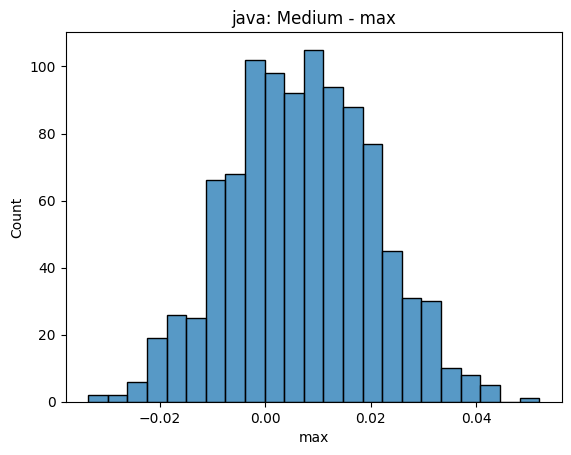

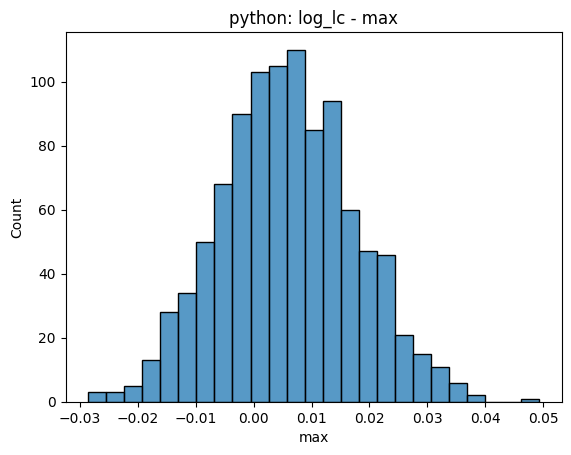

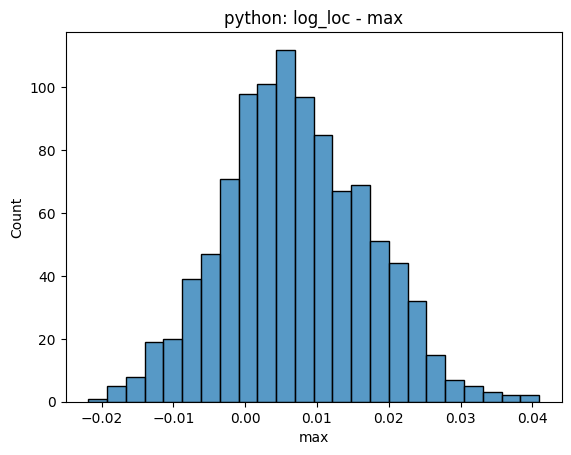

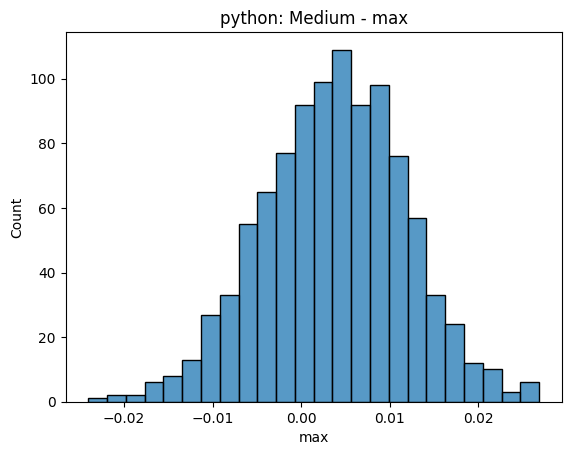

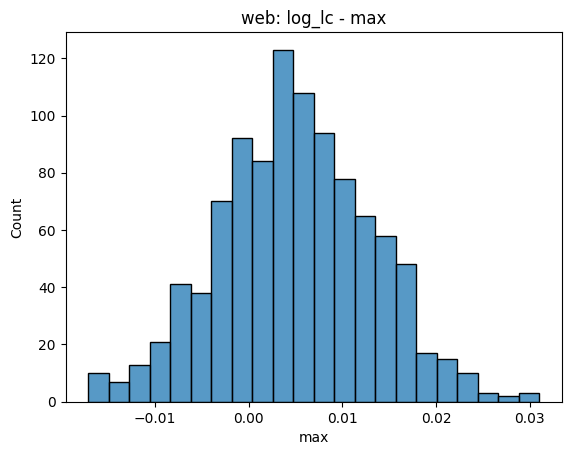

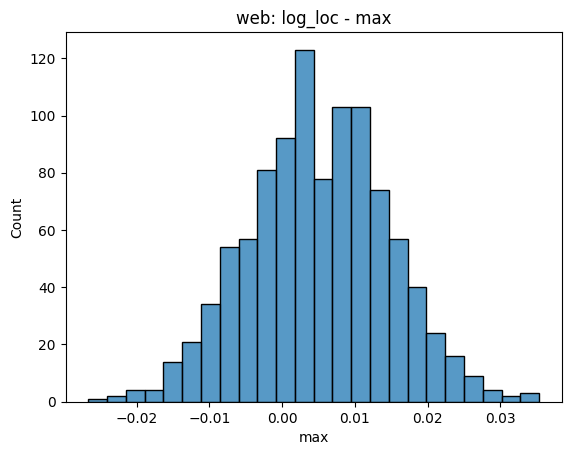

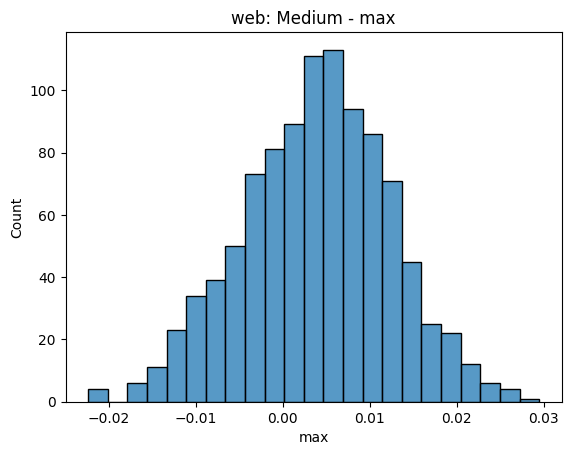

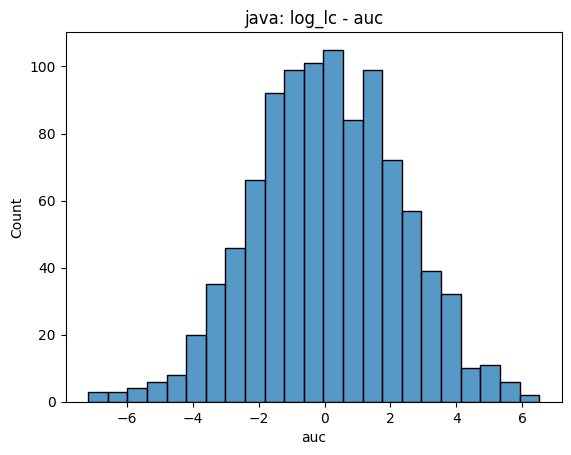

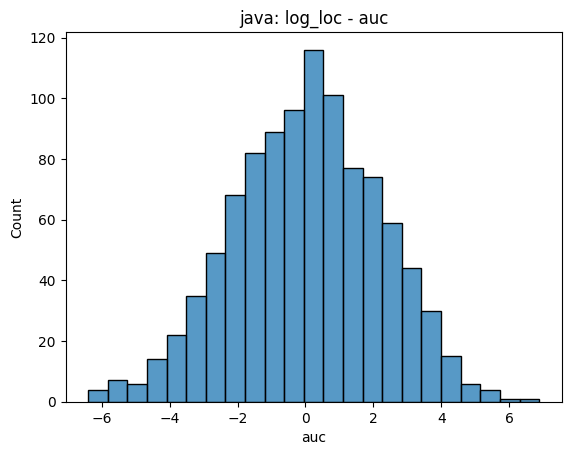

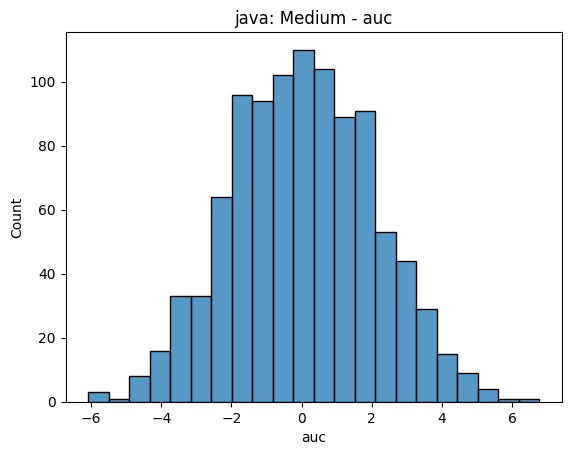

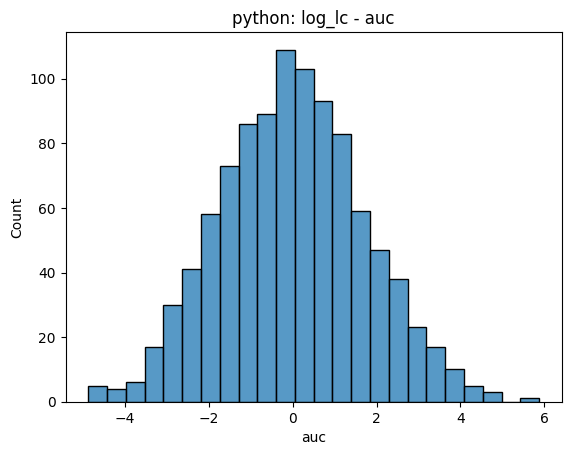

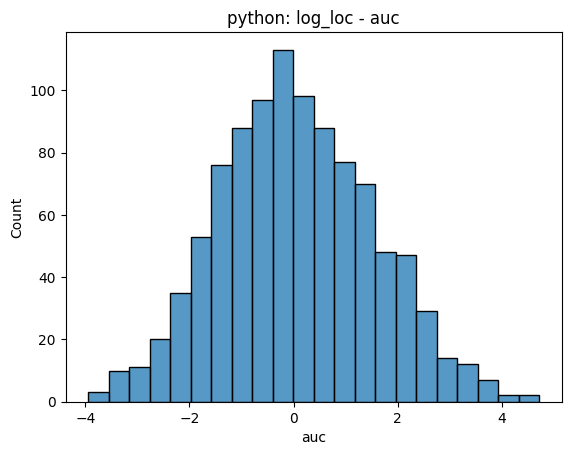

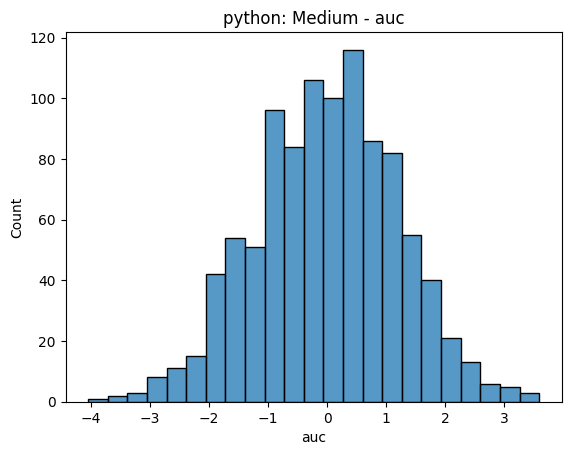

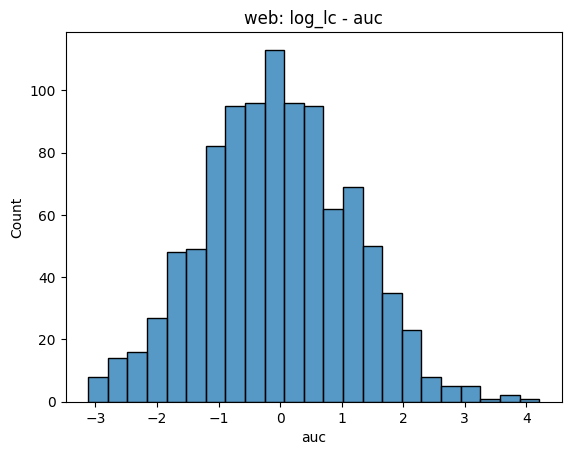

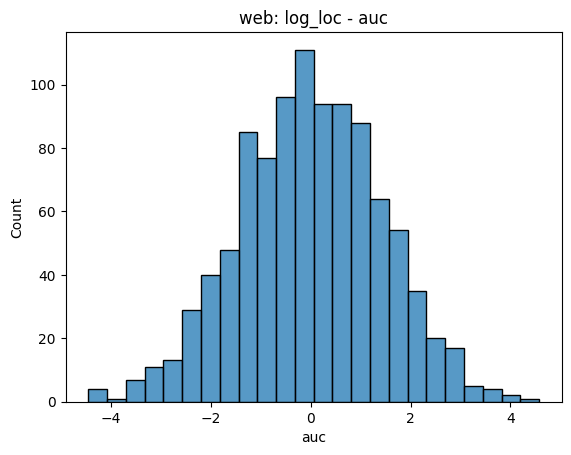

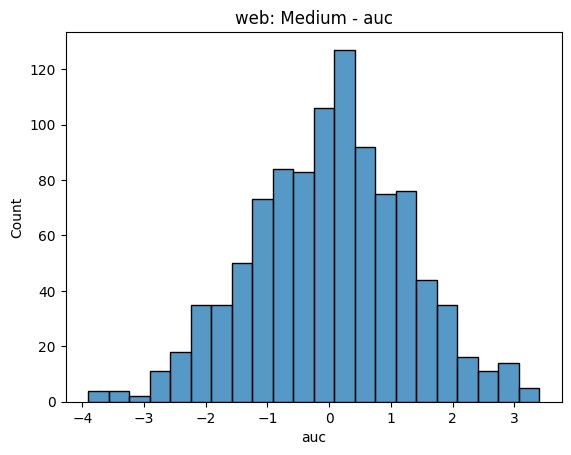

In [18]:
l_hats, m_hats, a_hats, boots = resample(tag_dfs, tag_results, outcomes, sample_function=so.permute_treatment)
so.store_results(boots, 'tags_perm.csv')
resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

In [19]:
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc']}

#placebo_t = '2023-02-28'
#placebo_c = '2022-02-28'
#shifted_t = (pd.to_datetime(placebo_t) - pd.DateOffset(months=6)).strftime("%Y-%m-%d")
#shifted_c = (pd.to_datetime(placebo_c) - pd.DateOffset(months=6)).strftime("%Y-%m-%d")

#shifted_str = shifted
placebo_t = ['2022-08-31', '2022-09-30', '2022-10-31']
placebo_c = ['2021-08-31', '2021-09-30', '2021-10-31']
shifted_t = [(pd.to_datetime(placebo) + pd.DateOffset(days=151)).strftime("%Y-%m-%d") for placebo in placebo_t]

#start_dates, masks = so.rolling_window_masks(q_daily, data_column='date', normalized=True, window_days=30, pre_end=placebo_t, pre_end_c=placebo_c, pre_start=shifted_t, pre_start_c=shifted_c)

results = {}
for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
             for pt, pc, st in zip(placebo_t, placebo_c, shifted_t):
                  print(f'Processing: {type} - {outcome} - {pt}')

                  start_dates, masks = so.rolling_window_masks(dfs[type], data_column='date', normalized=True, window_days=30, pre_end=pt, pre_end_c=pc, end=st)
                  daily = dfs[type].copy()
                  daily['P'] = (((daily['date'] >= pd.to_datetime(pt)) & (daily['date'] <= pd.to_datetime('2023-05-29'))) | 
                                ((daily['date'] >= pd.to_datetime(pc)) & (daily['date'] <= pd.to_datetime('2022-05-30')))).astype(int)
                  
                  X, y = so.did_design_matrix(f'{outcome}_bar', daily)
                  res = so.did_wls(daily, X, y, masks, start_dates, outcome)
                  results[(type, outcome, pt)] = res

Processing: questions - log_lc - 2022-08-31
Processing: questions - log_lc - 2022-09-30
Processing: questions - log_lc - 2022-10-31
Processing: answers - log_lc - 2022-08-31
Processing: answers - log_lc - 2022-09-30


/home/dhelic/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Processing: answers - log_lc - 2022-10-31


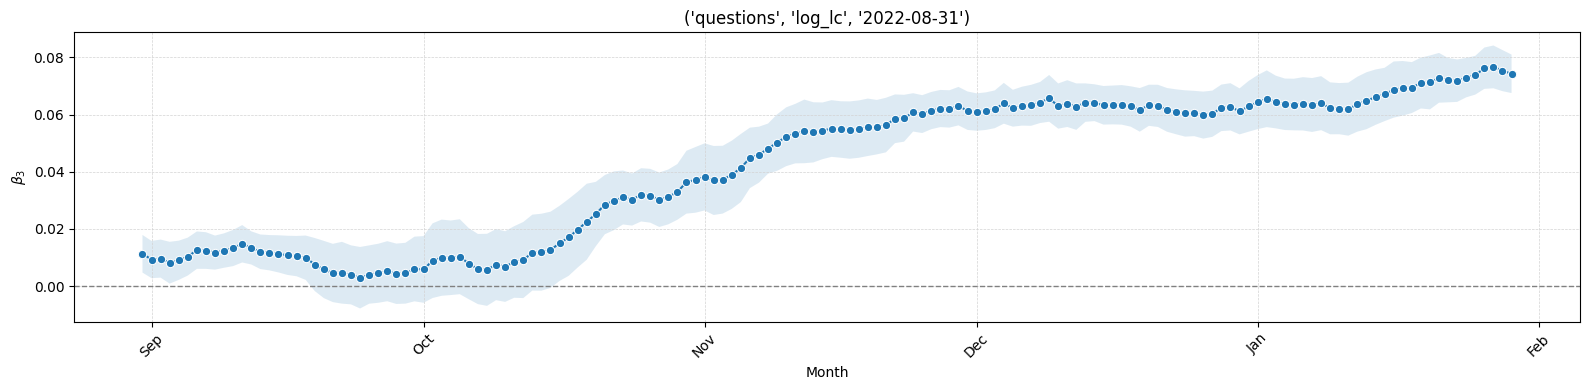

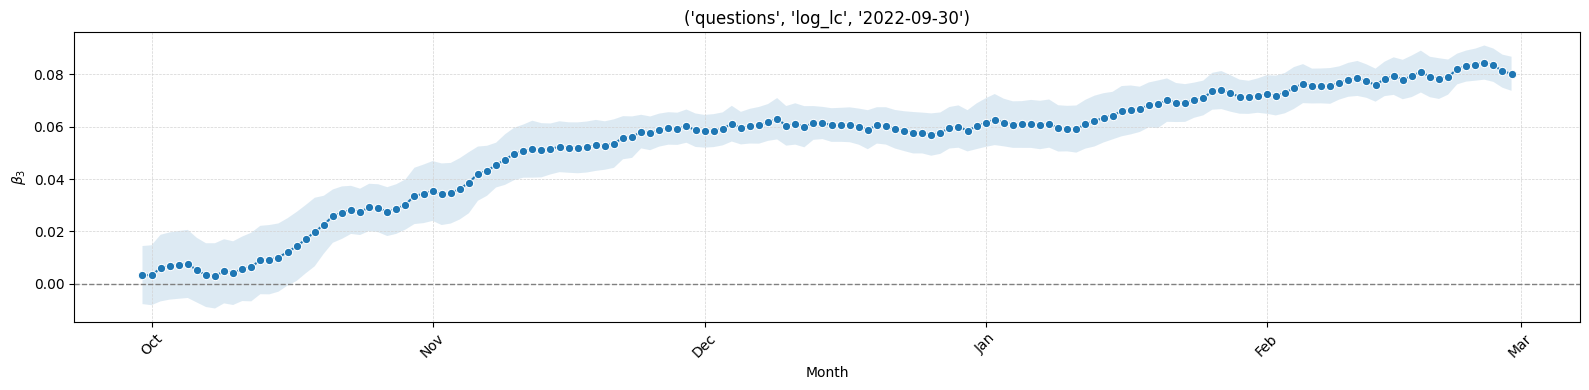

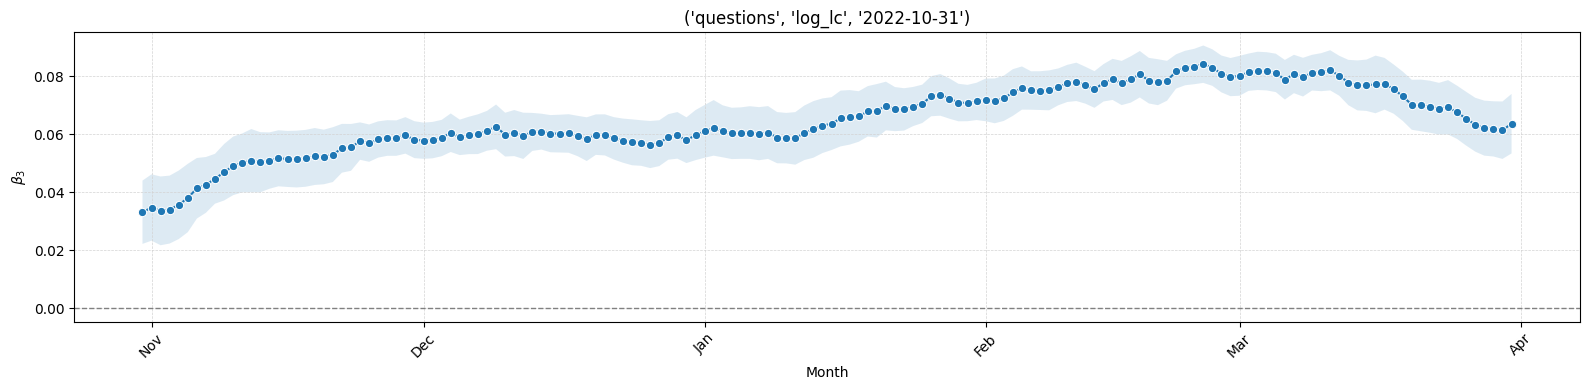

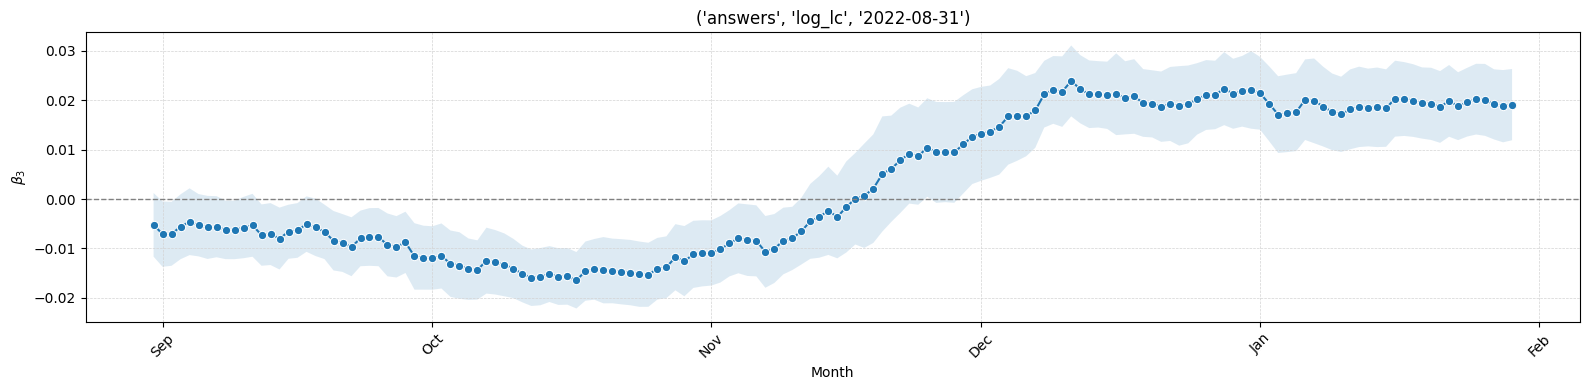

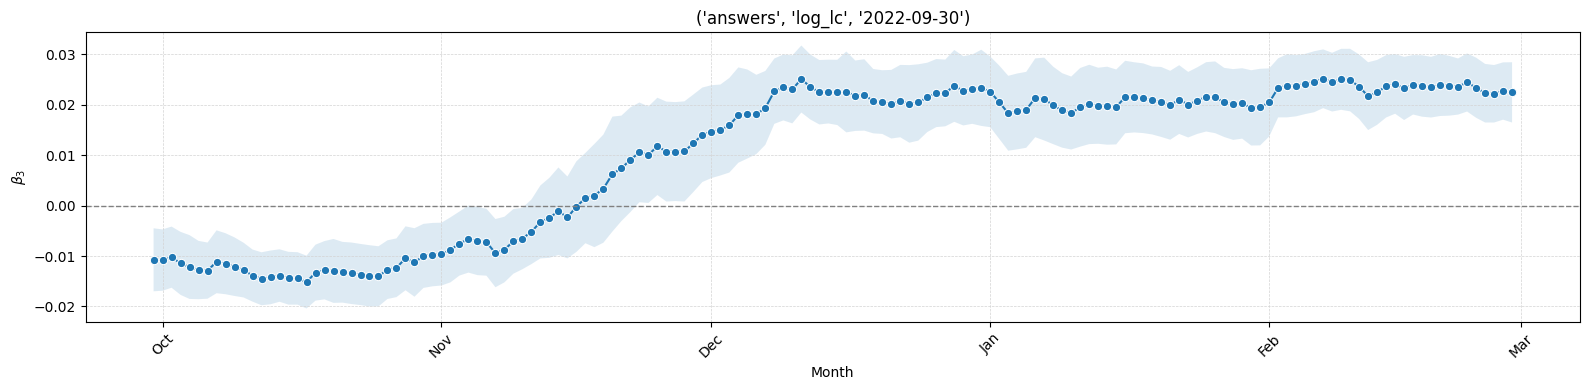

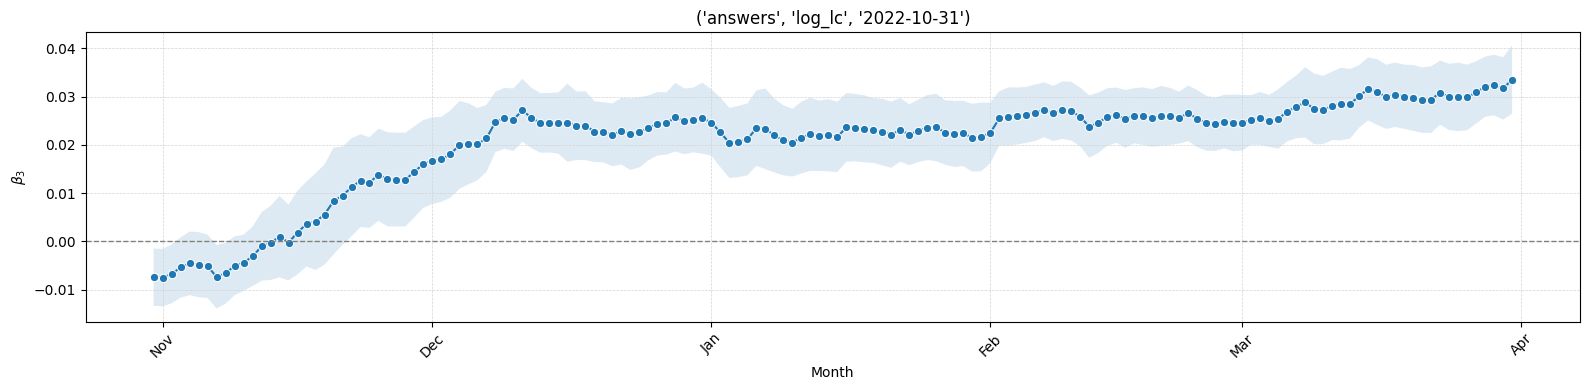

In [20]:
for key, df_res in results.items():
    so.plot_did(df_res, str(key), 'temp/temp.pdf')